# Analyse exploratoire, descriptive et inférentielle de données


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("join_total1.csv", low_memory=False)


In [8]:
print(df.head())


   sexeps  fqcantine  entrerep  colmata  distconf  distfruit  distsoli  \
0     2.0        9.0       4.0      4.0       NaN        NaN       NaN   
1     2.0        9.0       4.0      4.0       NaN        NaN       NaN   
2     2.0        9.0       4.0      4.0       NaN        NaN       NaN   
3     2.0        9.0       4.0      4.0       NaN        NaN       NaN   
4     2.0        9.0       4.0      4.0       NaN        NaN       NaN   

   fastfood  selassent  selassleg  ...  libelle_sexe   tri  mois  pm10  pm2_5  \
0       6.0        1.0        1.0  ...        hommes  10.0   NaN   NaN    NaN   
1       6.0        1.0        1.0  ...        hommes  10.0   NaN   NaN    NaN   
2       6.0        1.0        1.0  ...        femmes  10.0   NaN   NaN    NaN   
3       6.0        1.0        1.0  ...        hommes  10.0   NaN   NaN    NaN   
4       6.0        1.0        1.0  ...        femmes  10.0   NaN   NaN    NaN   

   carbon_monoxide  nitrogen_dioxide  sulphur_dioxide  ozone  grass_

# 1-Analyse exploratoire des données:
Nous essayons à travers cette analyse de mieux comprendre les données afin de pouvoir développer un modèle adéquat. Nos données ont été collectées pour étudier l'évolution des maladies chroniques respiratoires à travers leurs mise en lien avec le mode de vie, les habitudes alimentaires et la qualité de l'air.


## Analyse de Forme :
- **Variable target** : Ntop (nombre de patients atteints de maladie respiratoire chronique).
- **Lignes** : 1,048,575
- **Colonnes** : 200
- **Types de variables** :
  - Qualitatives : 9
  - Quantitatives : 191



In [11]:
df.shape

(1048575, 200)

In [12]:
print(df.duplicated())

0          False
1          False
2          False
3          False
4          False
           ...  
1048570    False
1048571    False
1048572    False
1048573    False
1048574    False
Length: 1048575, dtype: bool


In [13]:
df.drop_duplicates(inplace=True)

Malgré qu'il n'existe pas de lignes dupliquées dans notre Dataframe nous appliquons la suppression afin de pouvoir éliminer les lignes dupliquées si elles existents dans un autre Dataset surlequel on pourra tester notre modèle.

In [15]:
df.describe()

,sexeps,fqcantine,entrerep,colmata,distconf,distfruit,distsoli,fastfood,selassent,selassleg,...,prev,tri,mois,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,grass_pollen
count,763484.000000,1.045373e+06,1.045373e+06,605497.000000,218754.000000,218754.000000,218754.000000,1.045373e+06,1.045373e+06,1.045373e+06,...,1.031380e+06,1047764.0,251319.000000,251319.000000,251319.000000,251319.000000,251319.000000,251319.000000,251319.000000,167610.000000
mean,1.610964,7.278569e+00,3.818813e+00,3.833126,1.821292,1.879924,1.854014,6.243895e+00,1.636744e+00,1.862437e+00,...,5.656386e+00,10.0,6.499946,17.163427,11.016441,195.088580,19.118189,1.659537,50.103165,6.394018
std,0.487532,2.860559e+00,1.603419e+00,1.400386,0.383108,0.325051,0.353093,1.149003e+00,1.335478e+00,1.342267e+00,...,3.601015e+00,0.0,3.452075,4.193819,3.831266,42.851505,5.634086,0.641878,14.269440,9.189176
min,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,...,3.050000e-01,10.0,1.000000,11.204731,6.289140,134.194409,11.206452,0.753656,25.678444,0.000000
25%,1.000000,5.000000e+00,3.000000e+00,3.000000,2.000000,2.000000,2.000000,6.000000e+00,1.000000e+00,1.000000e+00,...,2.834000e+00,10.0,3.000000,14.448214,8.393978,153.204624,13.819355,1.269140,36.105780,0.005484
50%,2.000000,9.000000e+00,3.000000e+00,4.000000,2.000000,2.000000,2.000000,6.000000e+00,1.000000e+00,1.000000e+00,...,4.901000e+00,10.0,6.000000,15.870215,9.865054,193.869643,19.095714,1.555269,53.063556,1.166667
75%,2.000000,9.000000e+00,5.000000e+00,5.000000,2.000000,2.000000,2.000000,7.000000e+00,2.000000e+00,2.000000e+00,...,7.700000e+00,10.0,9.000000,20.839444,14.717204,226.335238,23.673548,1.788556,63.748889,7.955699
max,2.000000,9.000000e+00,9.000000e+00,9.000000,2.000000,2.000000,2.000000,9.000000e+00,9.000000e+00,9.000000e+00,...,2.282900e+01,10.0,12.000000,29.537312,21.718065,272.903222,30.134667,3.265161,70.435376,29.808889


# Types des variables


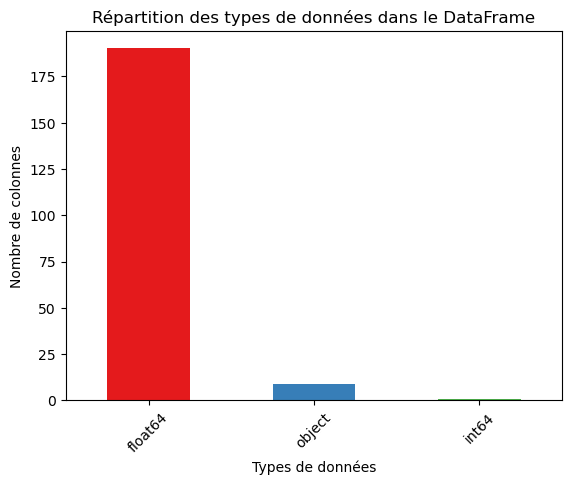

In [17]:

# Compter le nombre de colonnes de chaque type de données
type_counts = df.dtypes.value_counts()

# Créer une palette de couleurs pour les types de données
colors = sns.color_palette("Set1", len(type_counts))


ax = type_counts.plot(kind='bar', color=colors)


plt.title("Répartition des types de données dans le DataFrame")
plt.xlabel("Types de données")
plt.ylabel("Nombre de colonnes")

plt.xticks(rotation=45)  
plt.show()



## Analyse des valeurs manquantes :

    

In [19]:
# Calcul du pourcentage des valeurs manquantes par colonne
pourcentage_colonne = (df.isnull().sum() / df.shape[0]) * 100

# Afficher le pourcentage des valeurs manquantes
print(pourcentage_colonne)

sexeps              27.188422
fqcantine            0.305367
entrerep             0.305367
colmata             42.255251
distconf            79.137973
                      ...    
carbon_monoxide     76.032330
nitrogen_dioxide    76.032330
sulphur_dioxide     76.032330
ozone               76.032330
grass_pollen        84.015450
Length: 200, dtype: float64


les valeurs manquantes ainsi affichées varient entre 20% et 85% selon les colonnes. ceci n'implique pas forcément des suppressions des colonnes concernées vus que pour certaines comme grass_pollen se traduisent par la saisonalité d'appartition du ce phénomène.

## Pourcentage total des valeurs manquantes


In [22]:
# Calcul du nombre total de valeurs manquantes
total_nan = df.isnull().sum().sum()

# Calculer le nombre total de valeurs dans le DataFrame
total_val = df.size

# Calculer le pourcentage total de valeurs manquantes
pourcentage_total_nan = (total_nan/ total_val) * 100

# Afficher le pourcentage total des valeurs manquantes
print(f"Pourcentage total des valeurs manquantes : {pourcentage_total_nan:.2f}%")


Pourcentage total des valeurs manquantes : 38.13%


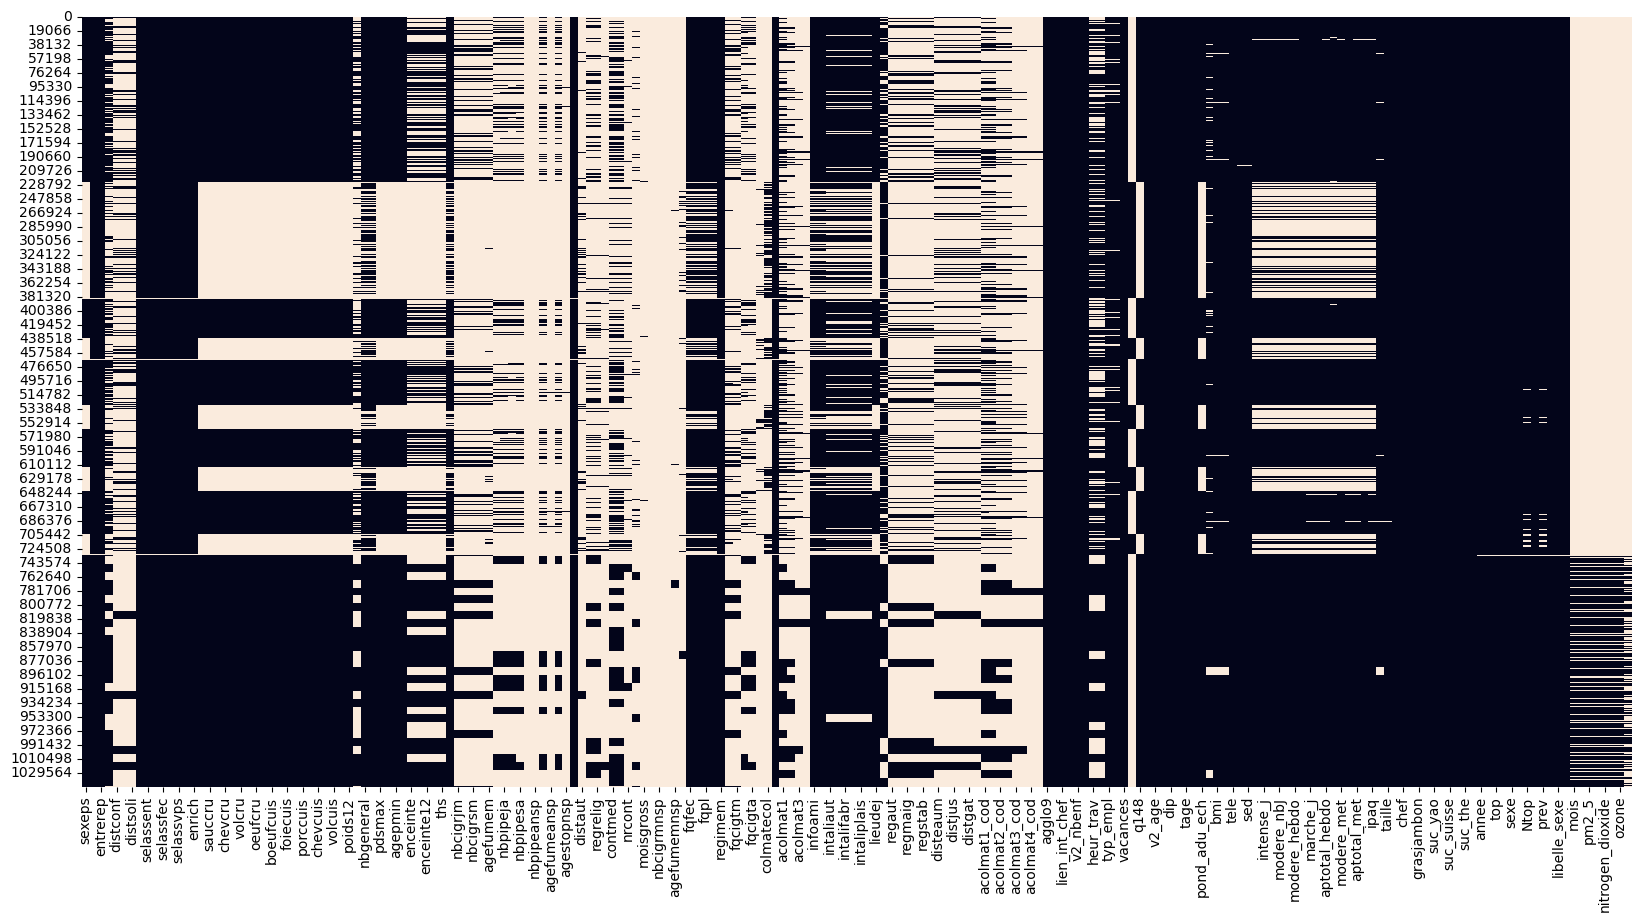

In [21]:
##Visualisation des valeurs nulles
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)
plt.show()


Ce heatmap nous indique la distribution des valeurs manquantes dans notre dataframe, et ainsi nous avons repéré par la couleur claire 
les colonnes avec une totalité de valeurs nulles qui sont à supprimer. 

## Analyse de Fond :
-  Etude Visualisation des données
  

In [24]:
# Afficher la distribution des types de données
print(df.dtypes.value_counts())


float64    190
object       9
int64        1
Name: count, dtype: int64


### Visualisation des données continues

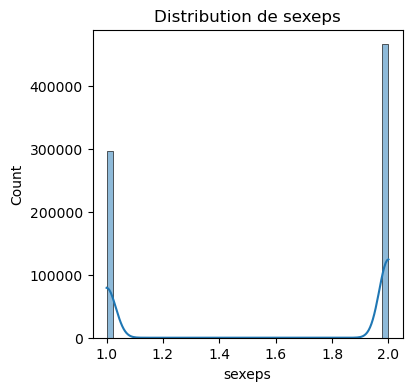

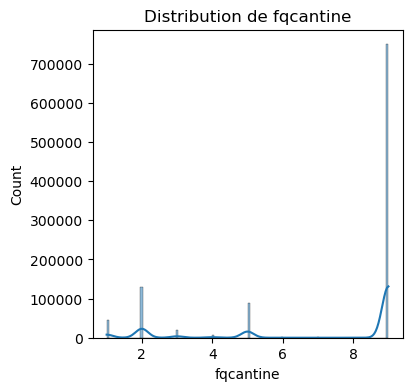

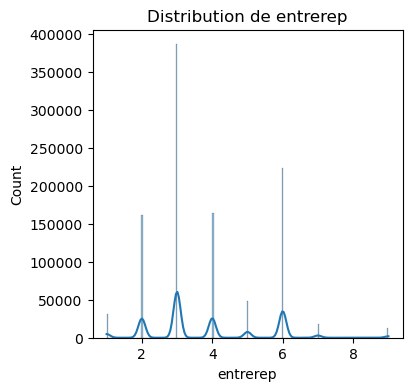

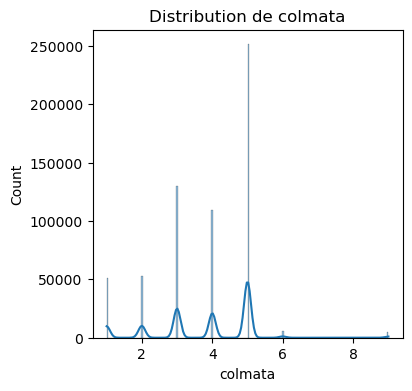

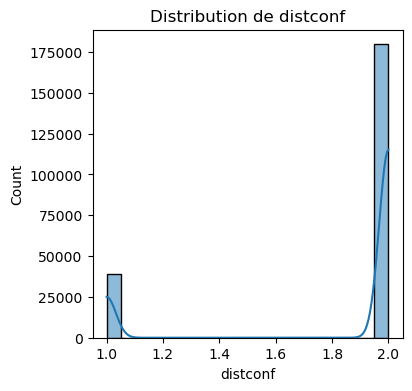

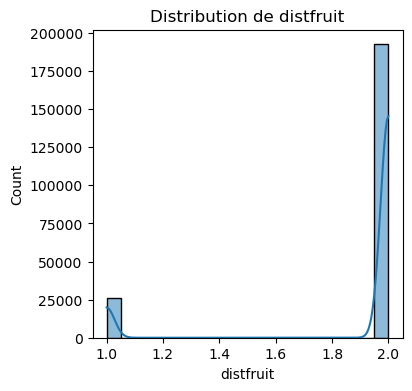

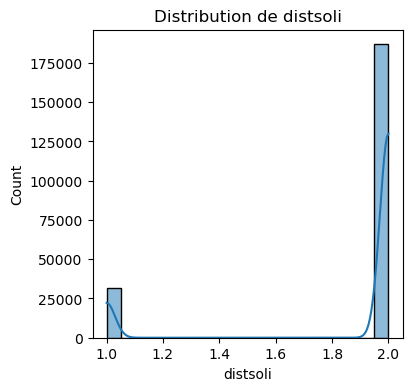

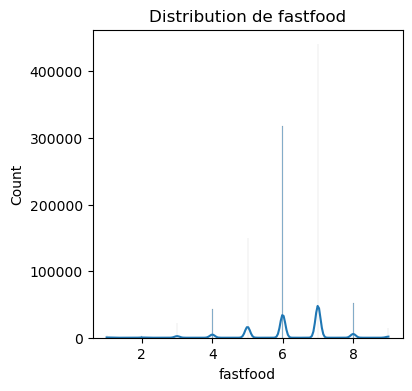

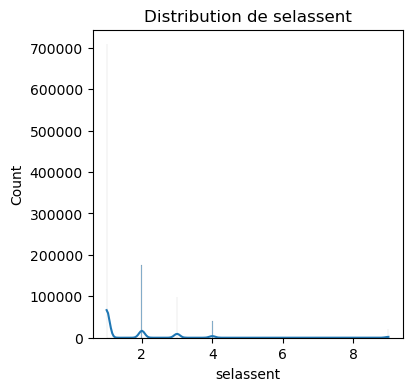

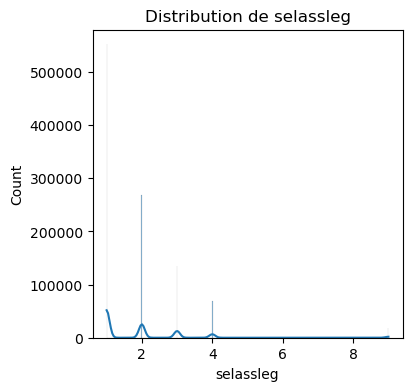

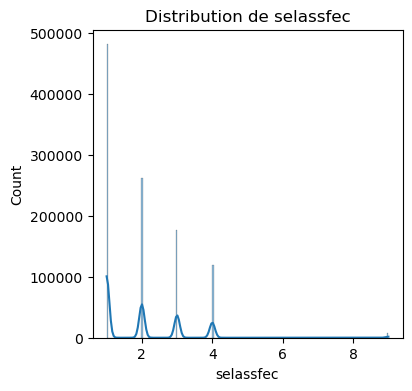

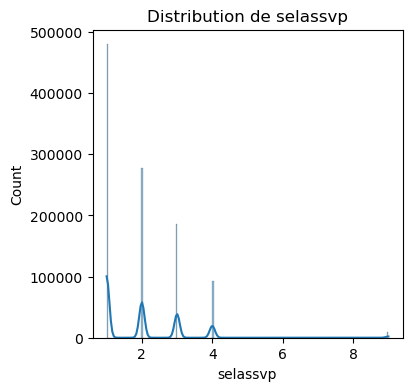

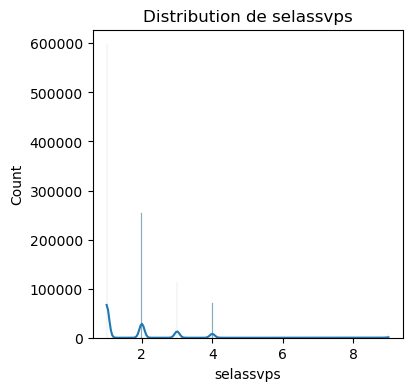

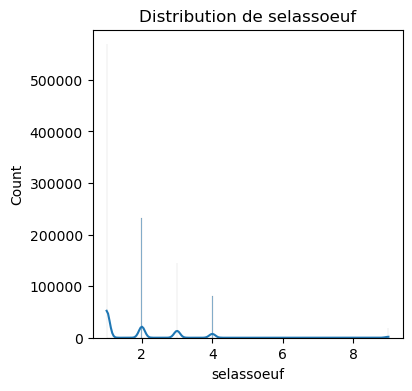

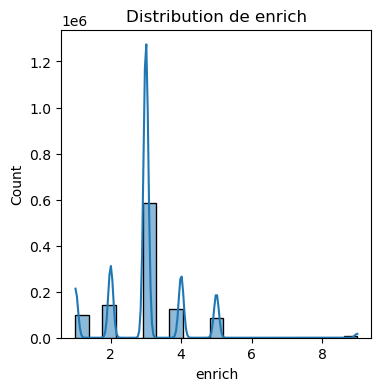

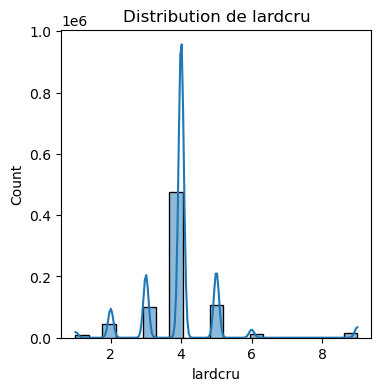

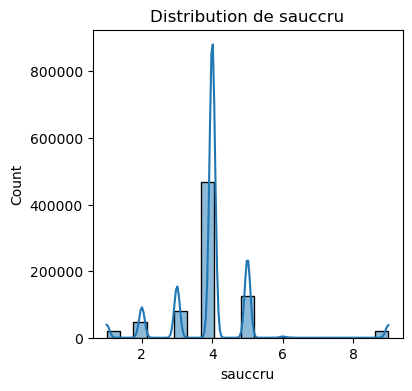

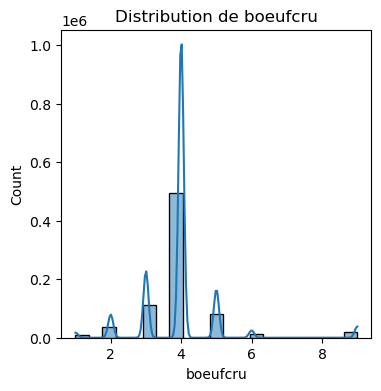

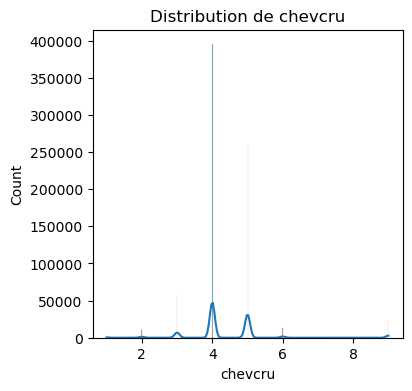

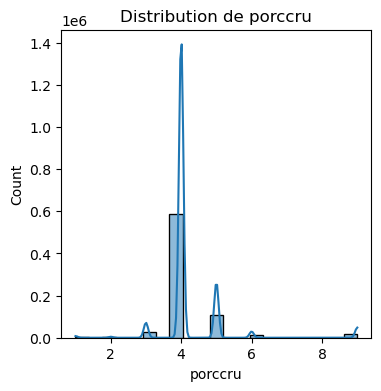

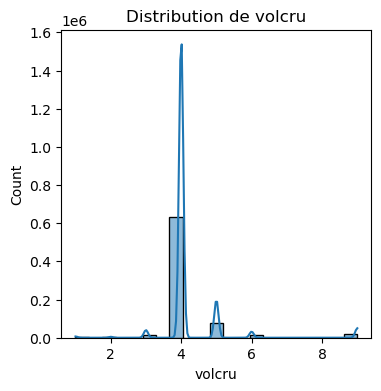

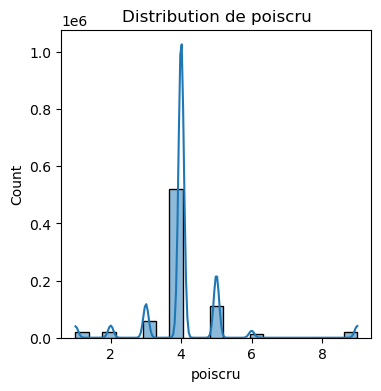

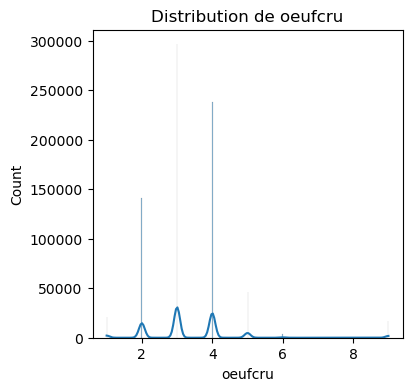

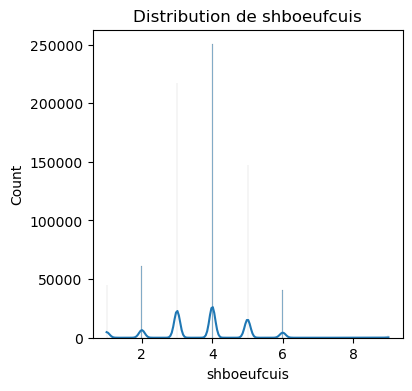

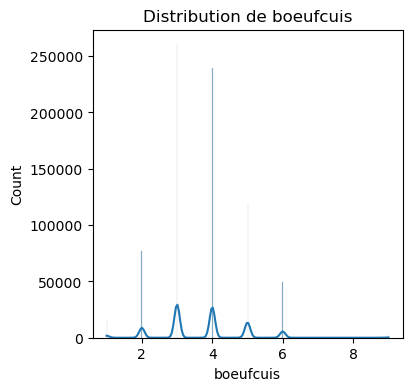

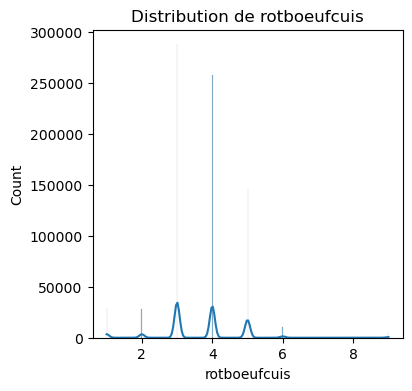

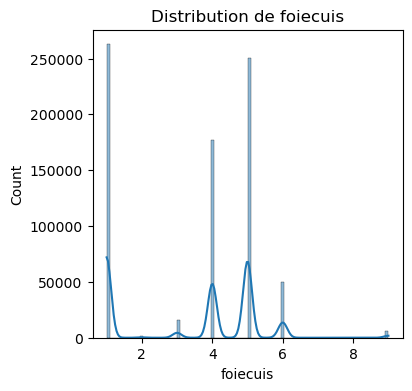

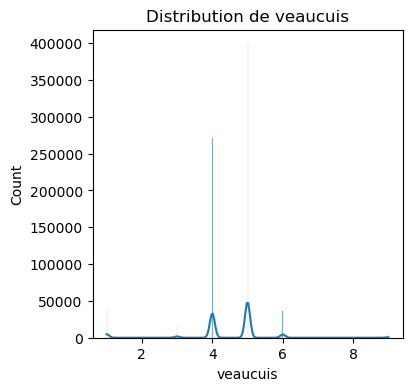

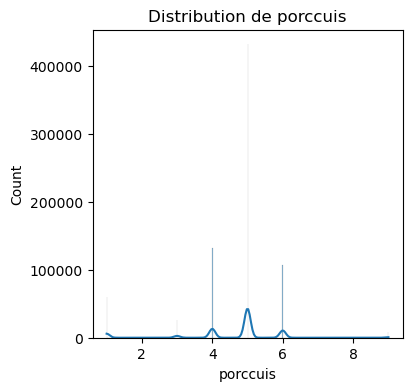

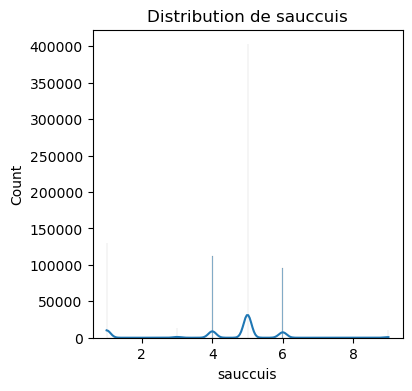

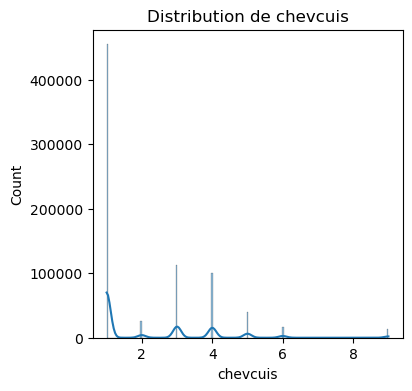

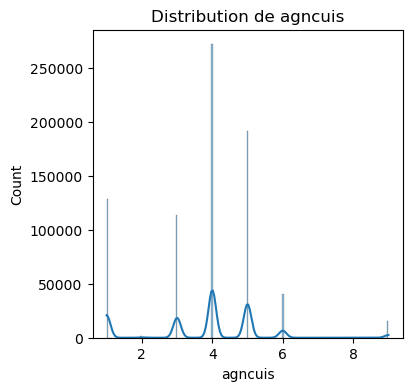

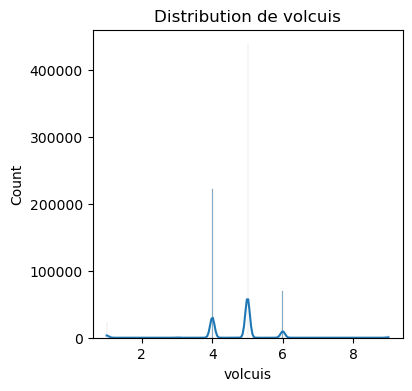

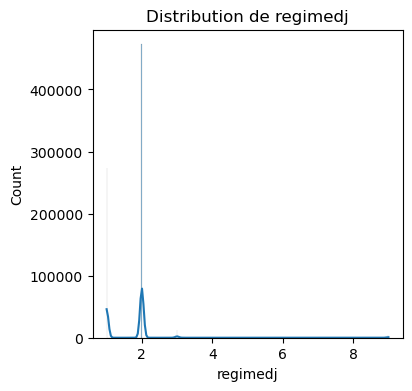

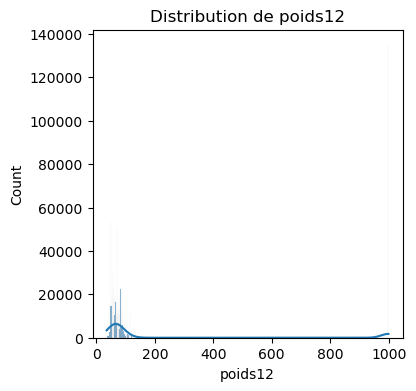

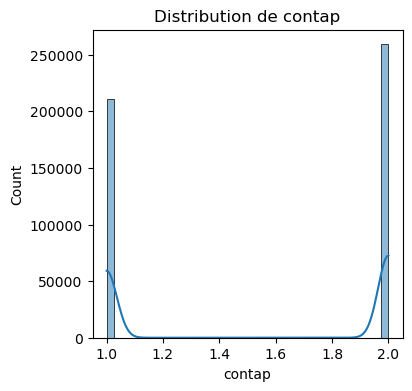

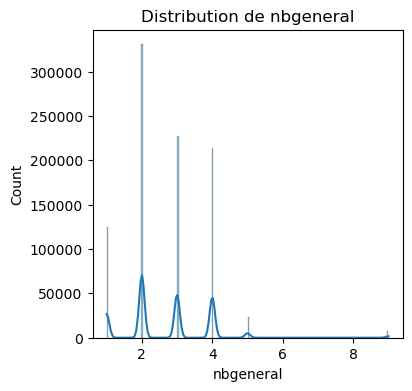

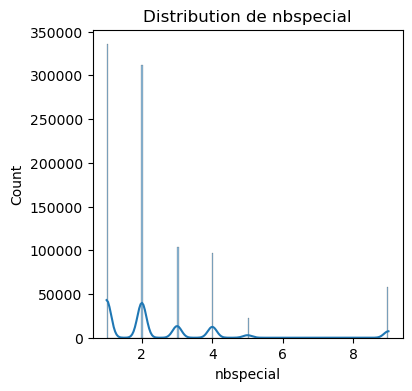

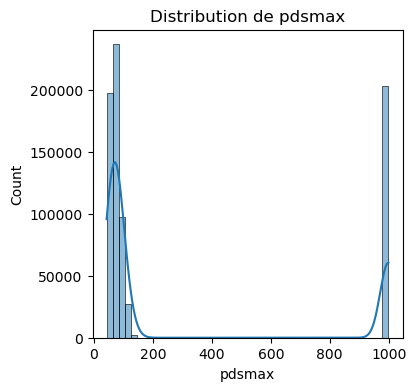

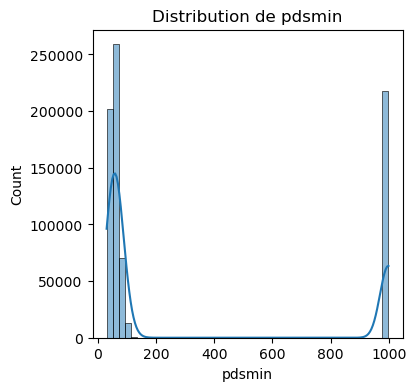

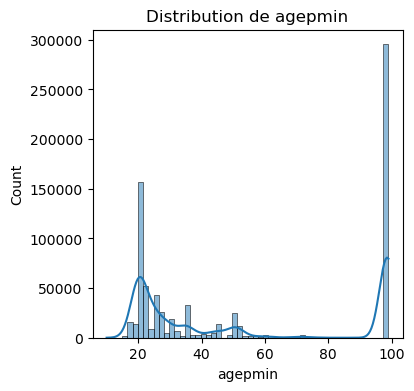

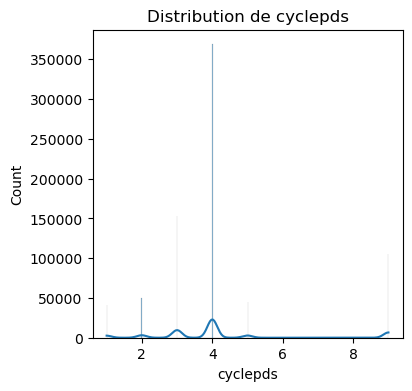

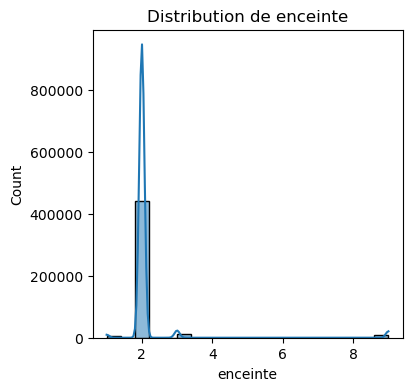

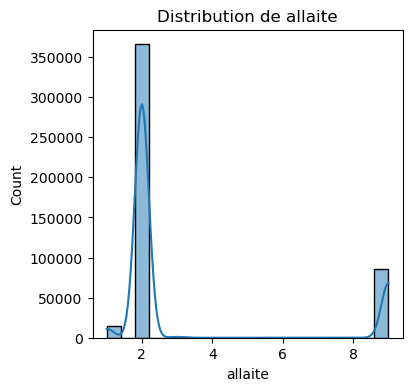

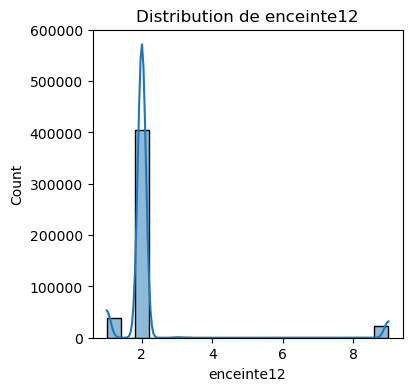

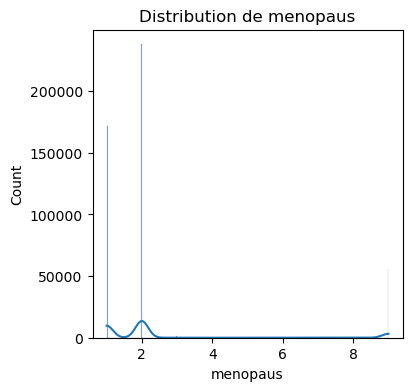

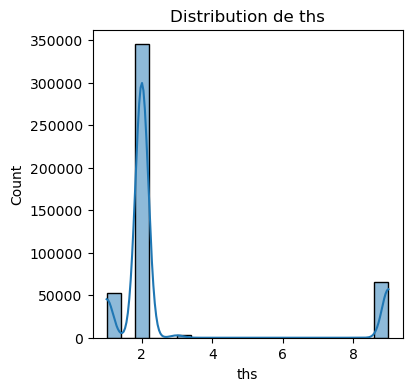

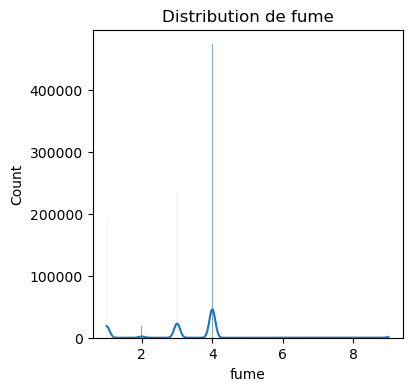

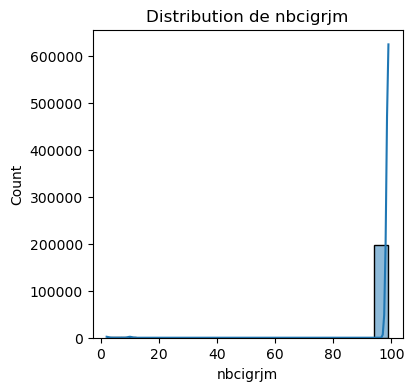

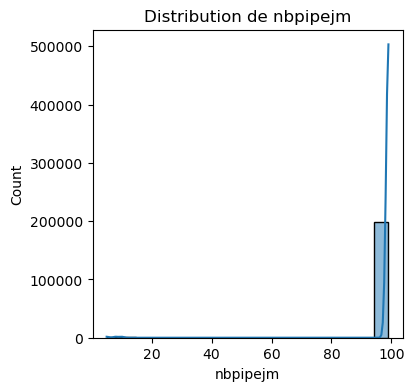

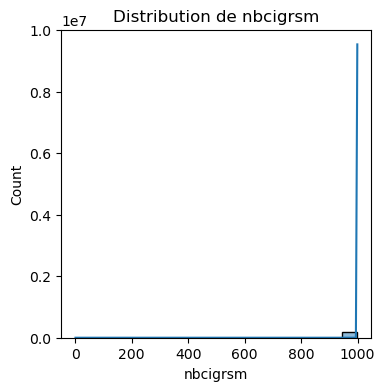

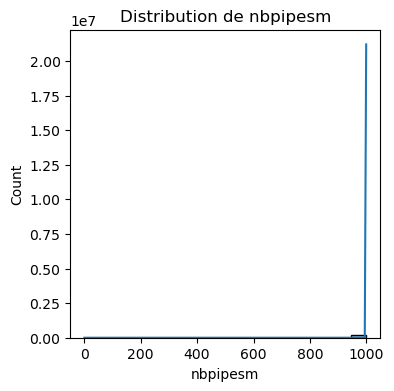

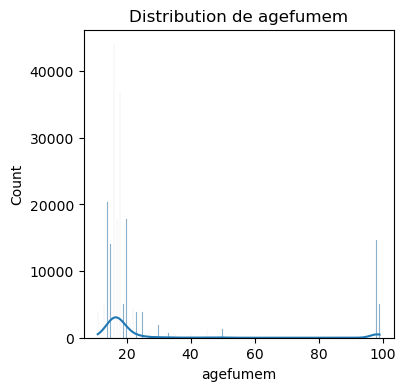

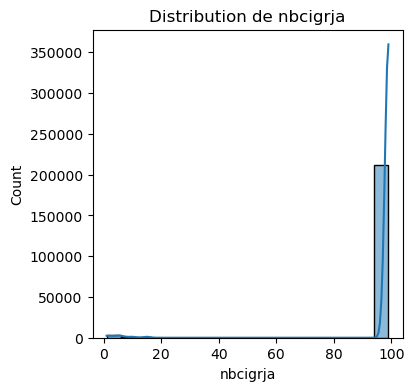

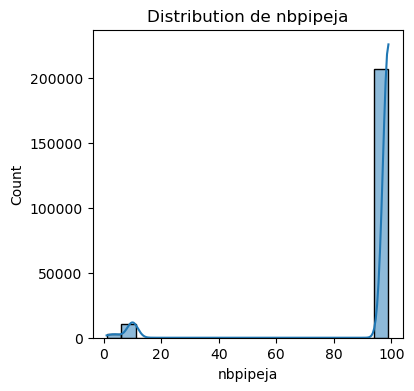

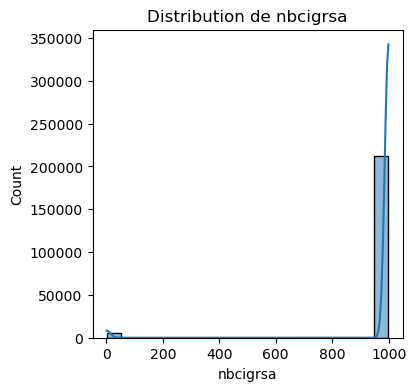

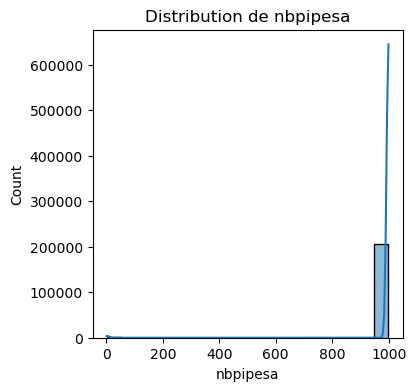

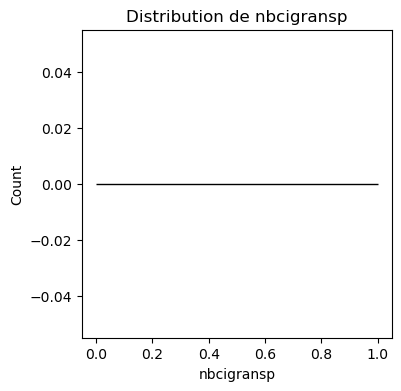

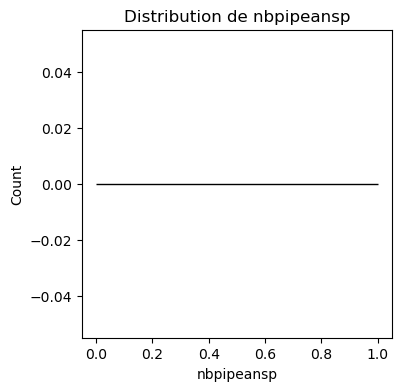

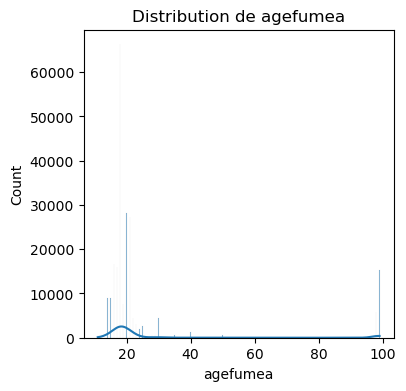

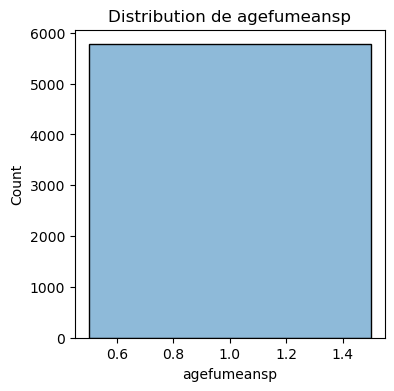

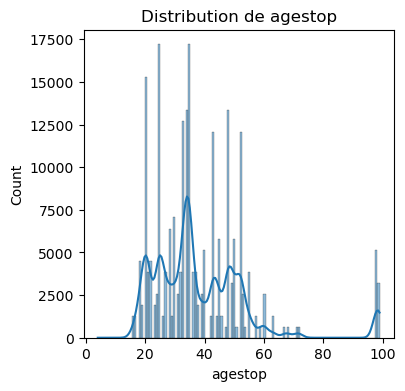

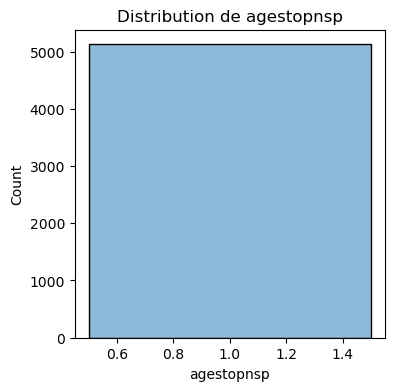

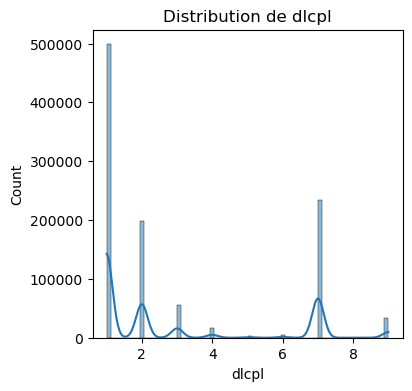

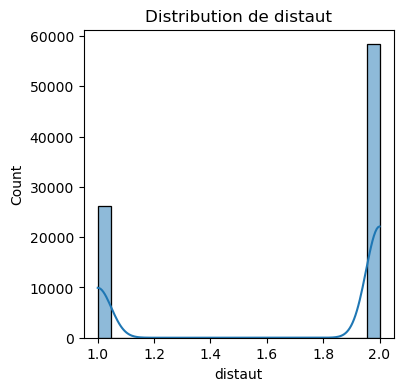

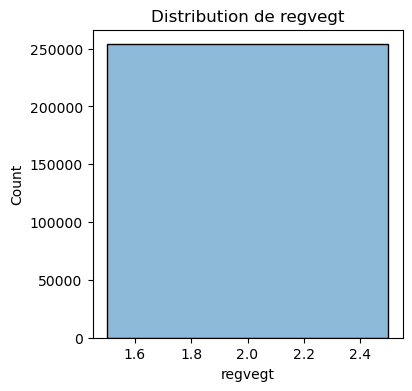

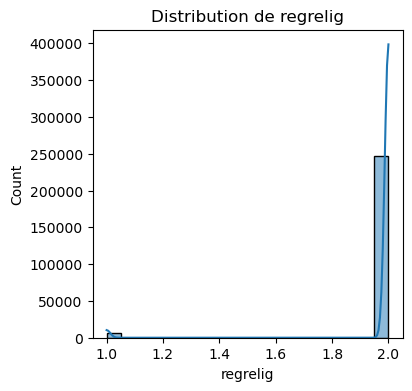

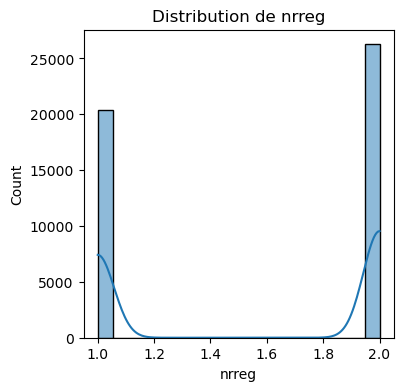

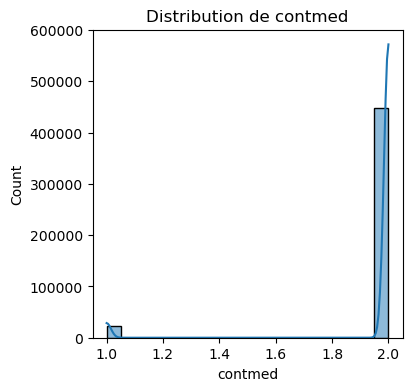

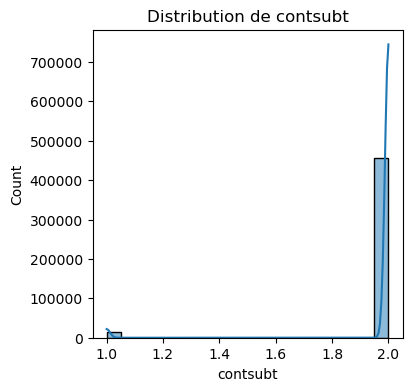

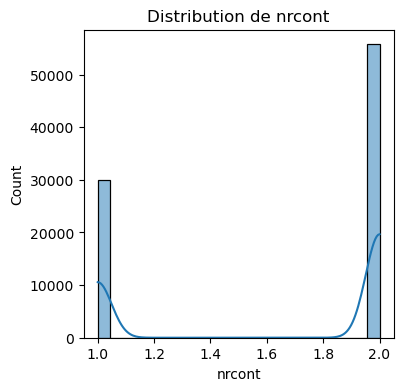

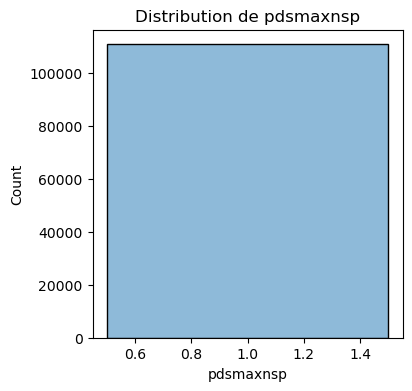

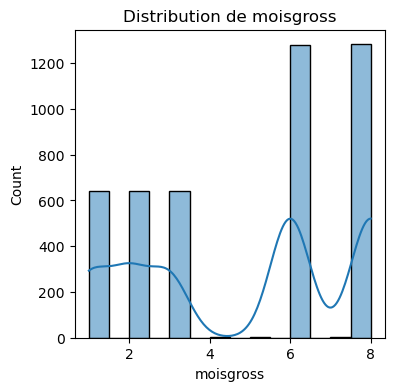

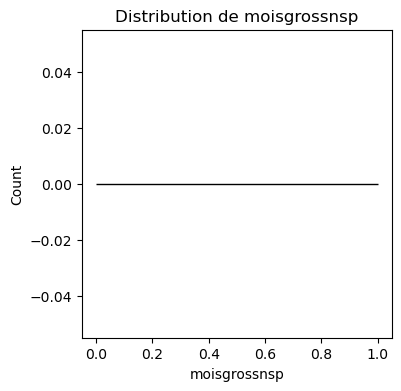

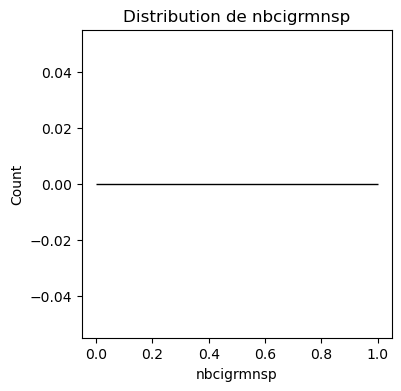

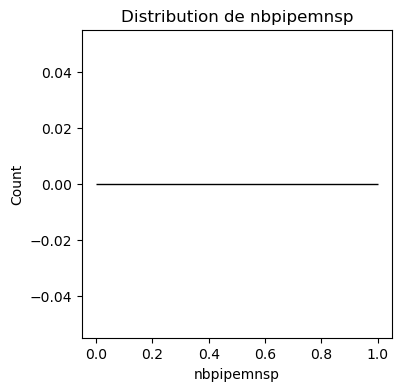

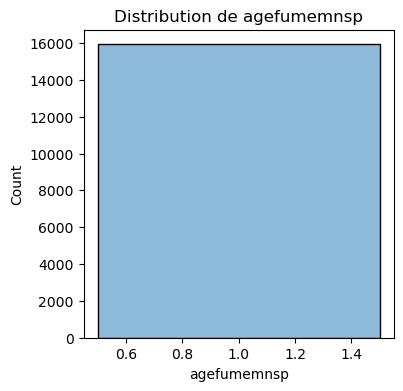

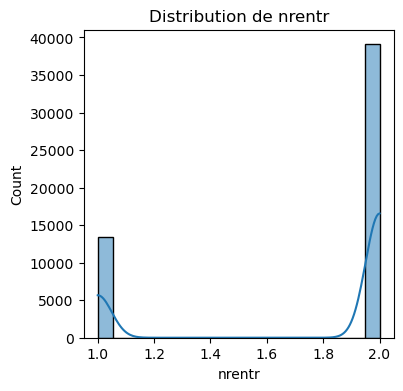

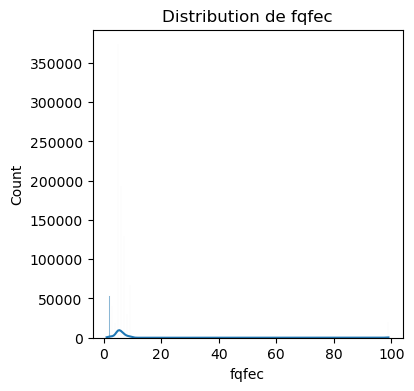

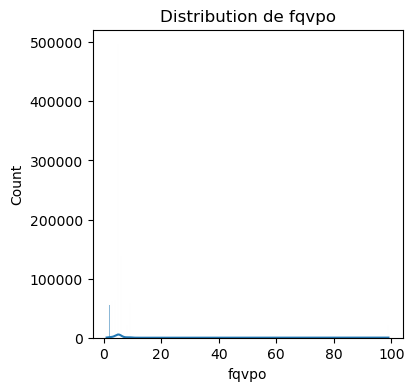

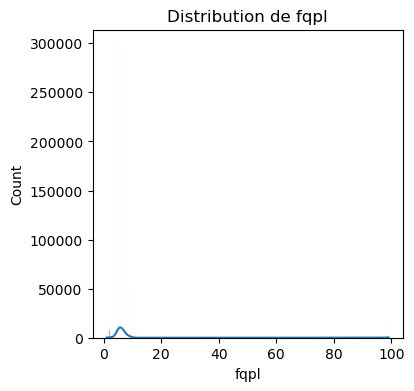

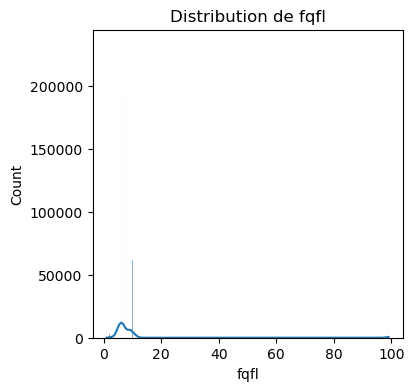

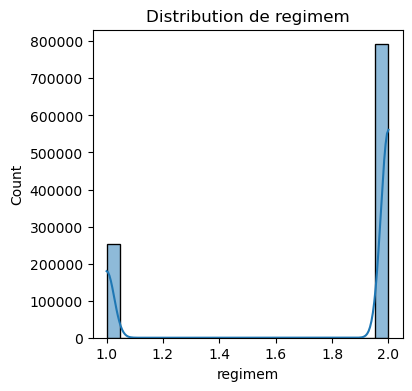

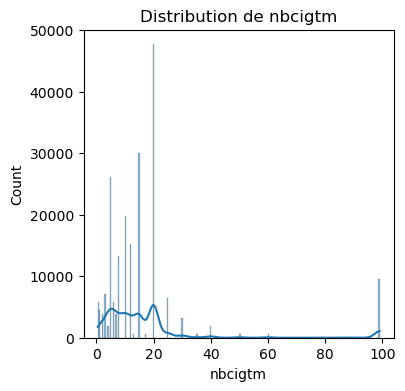

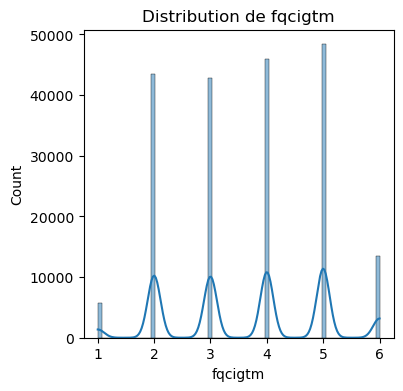

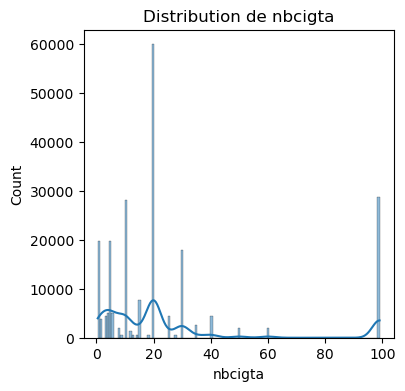

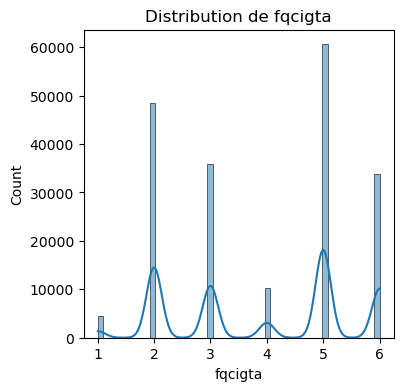

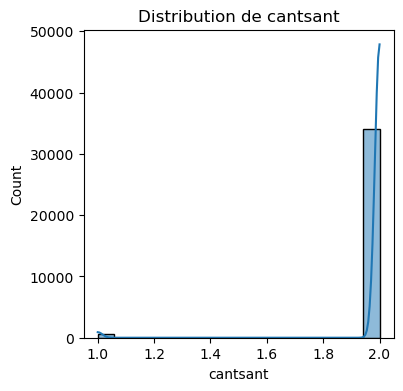

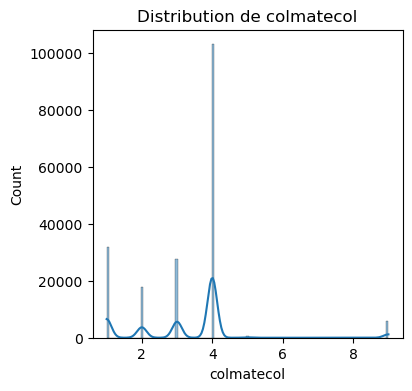

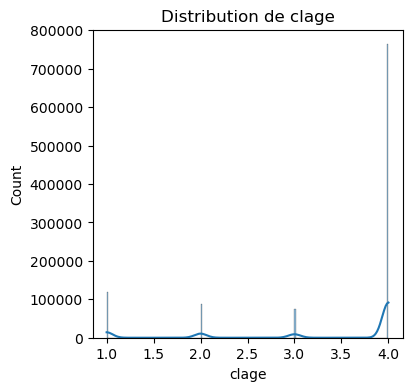

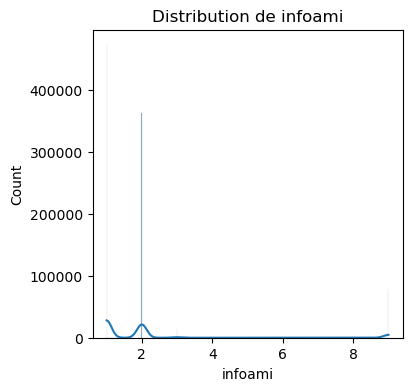

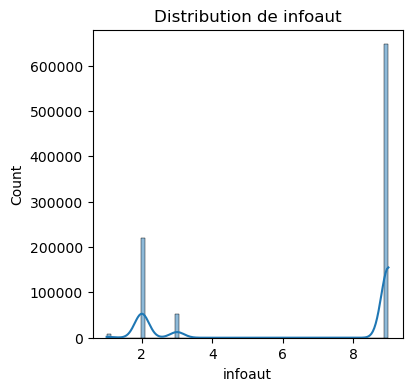

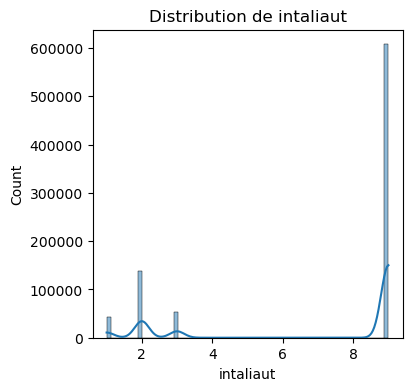

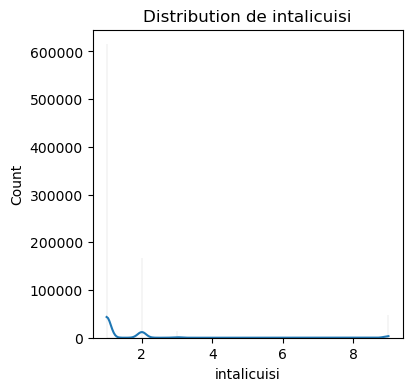

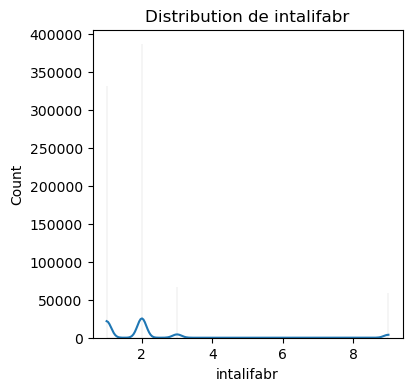

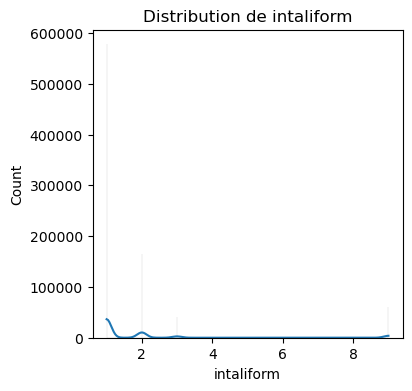

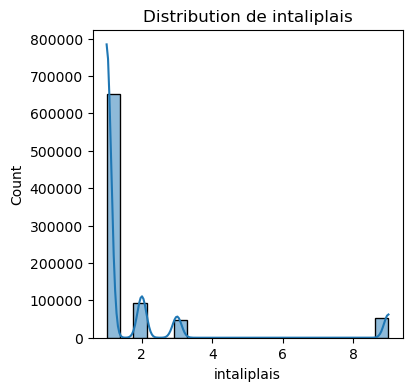

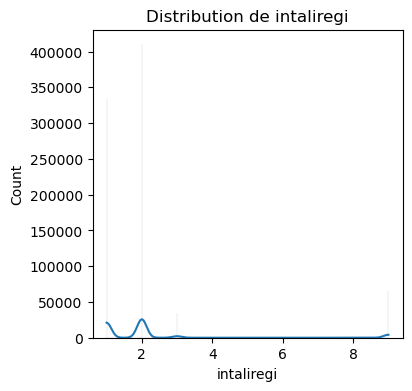

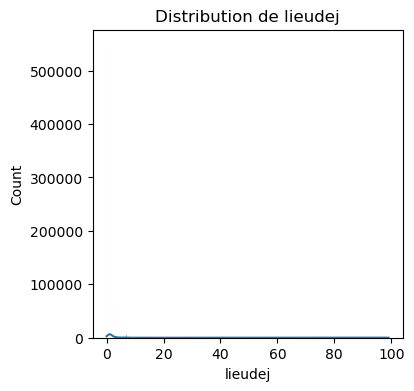

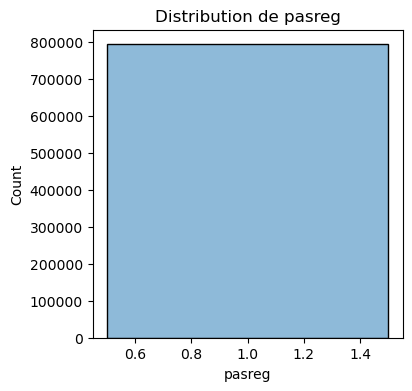

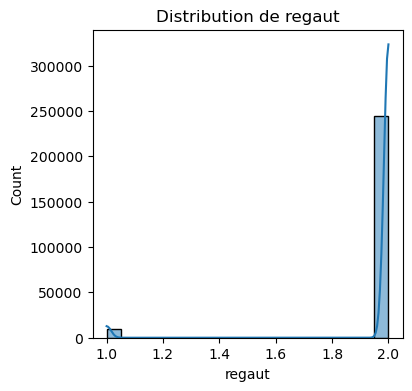

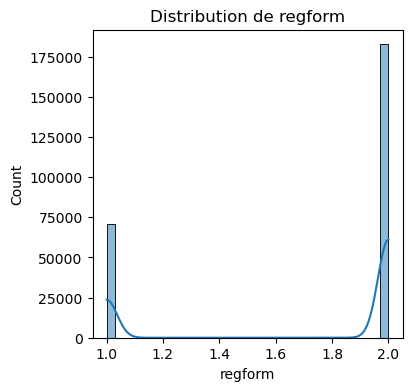

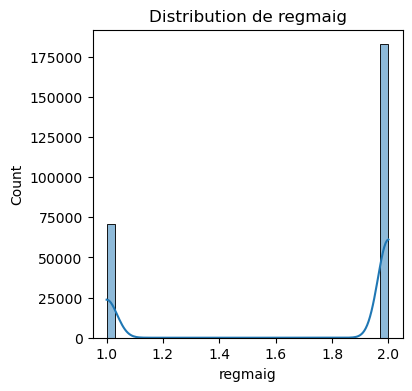

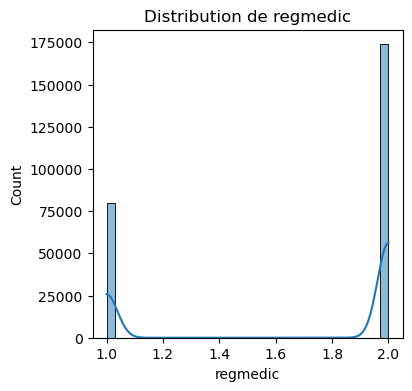

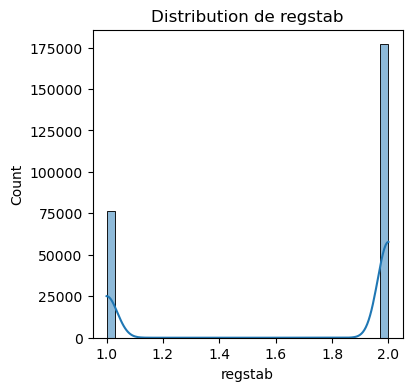

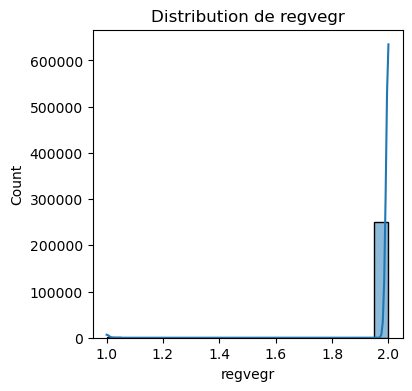

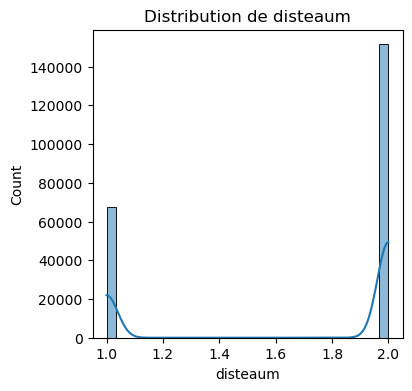

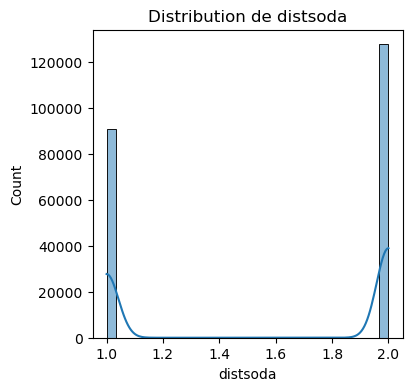

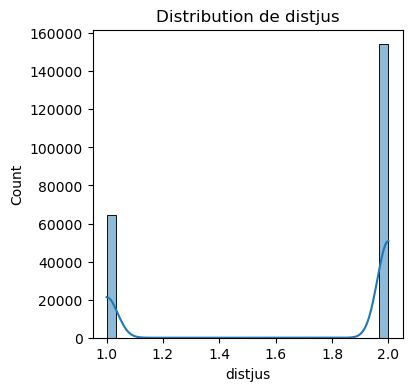

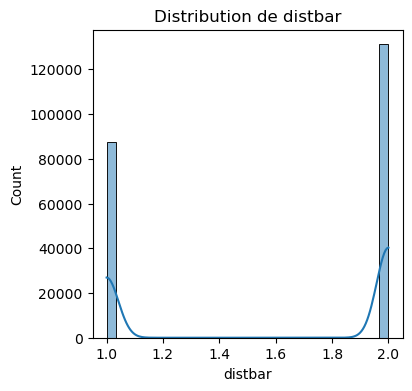

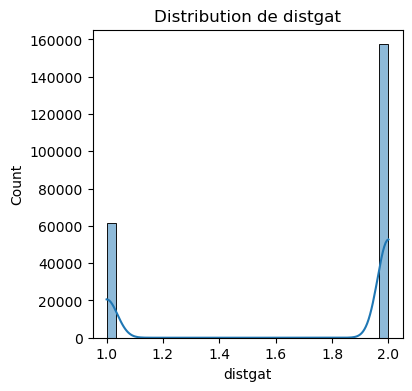

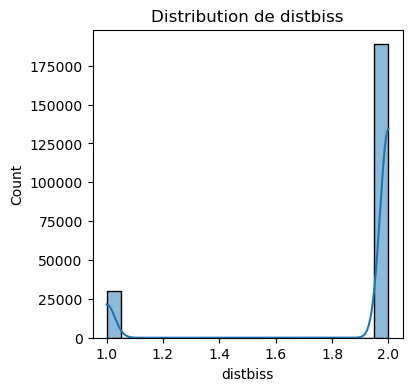

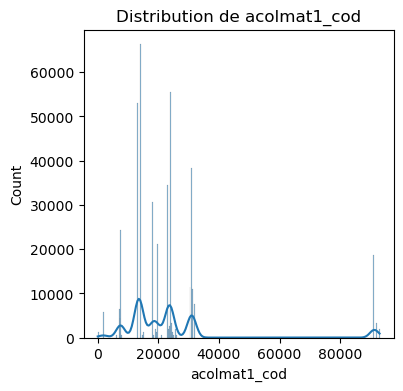

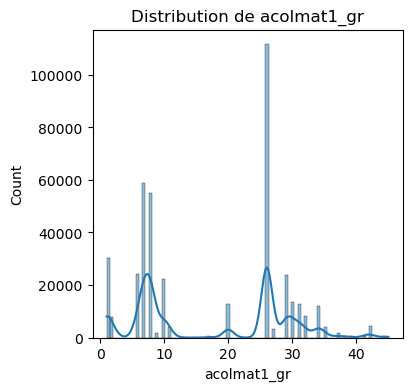

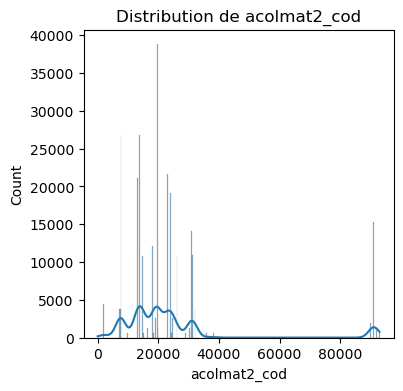

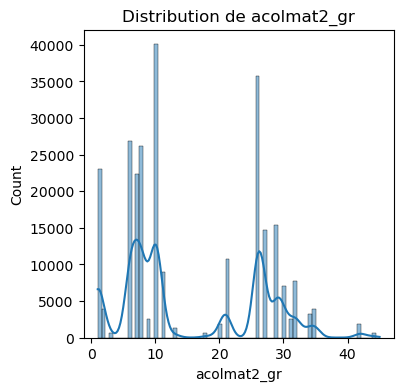

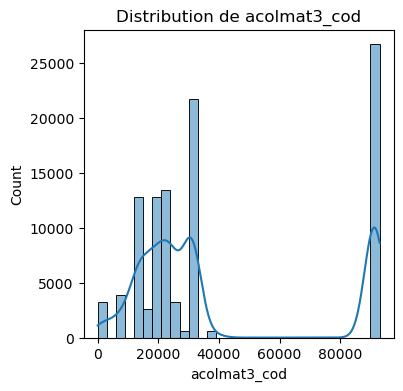

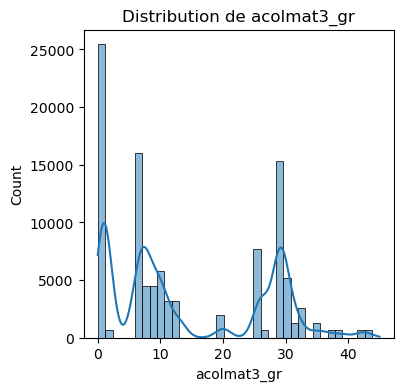

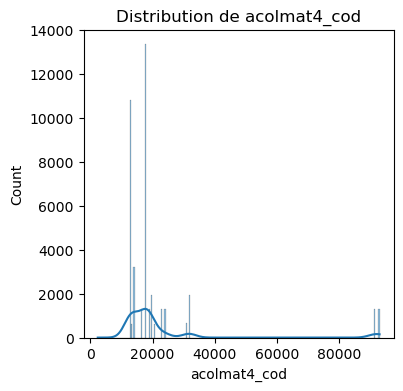

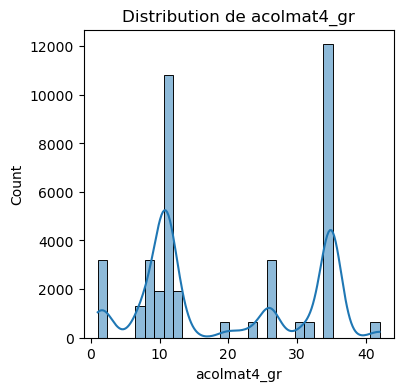

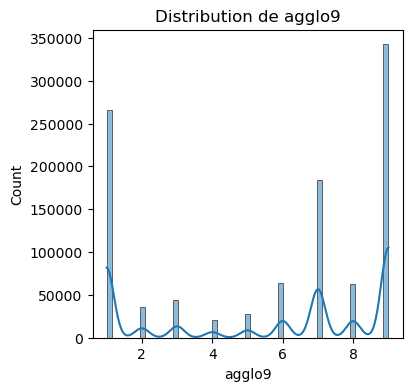

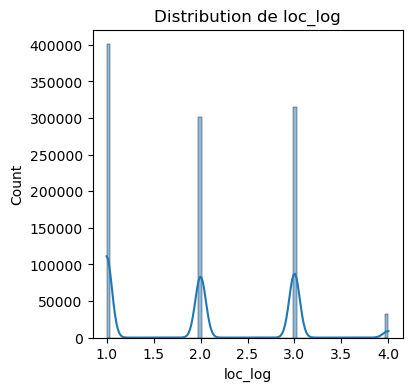

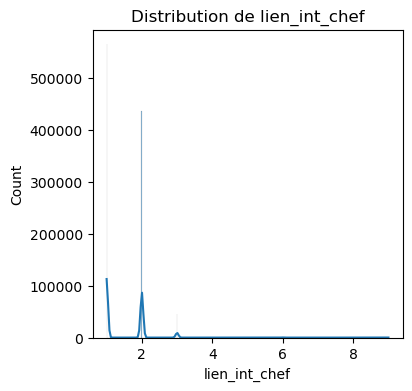

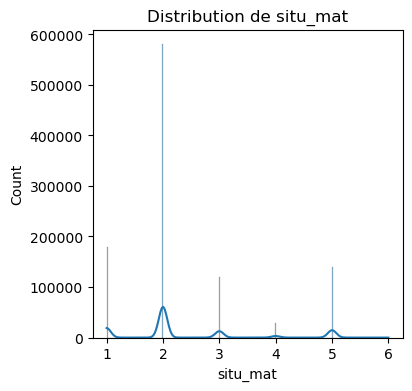

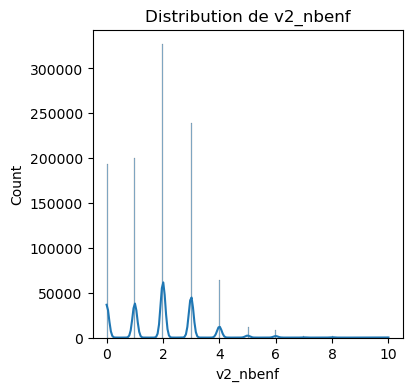

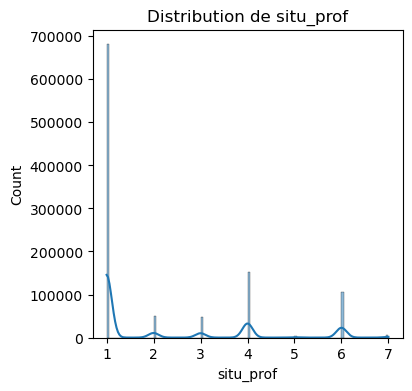

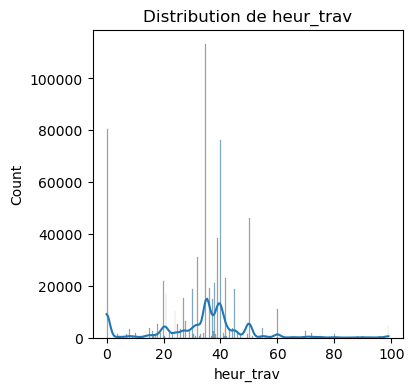

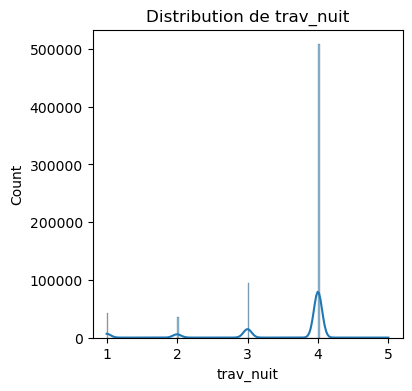

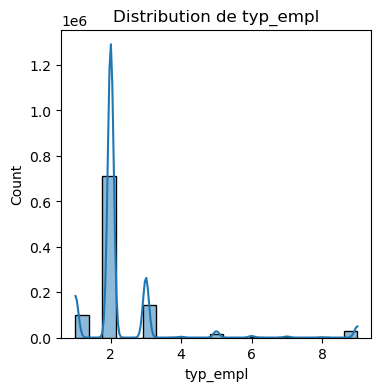

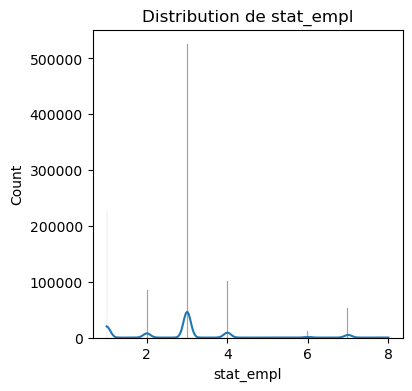

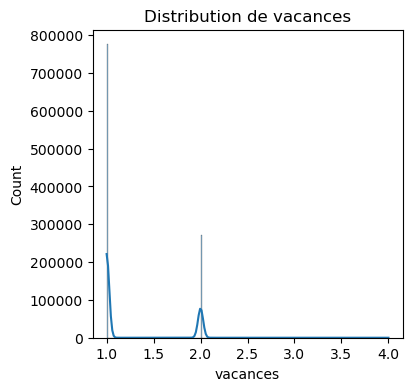

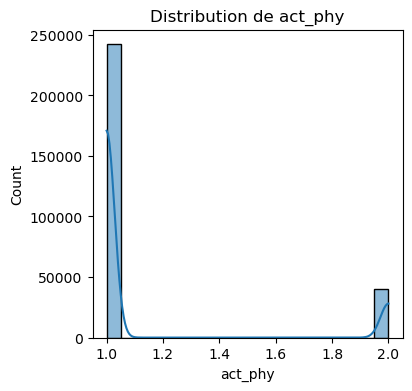

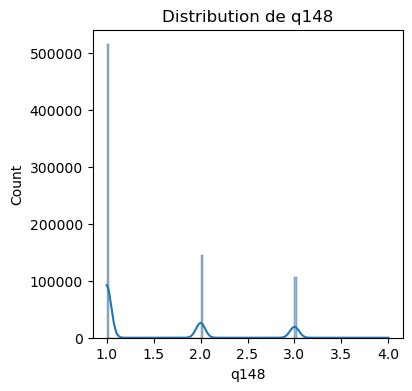

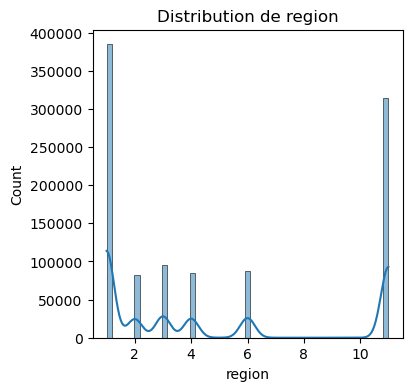

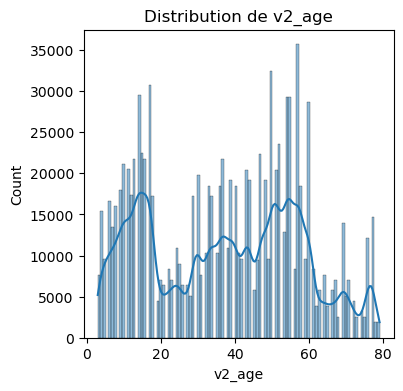

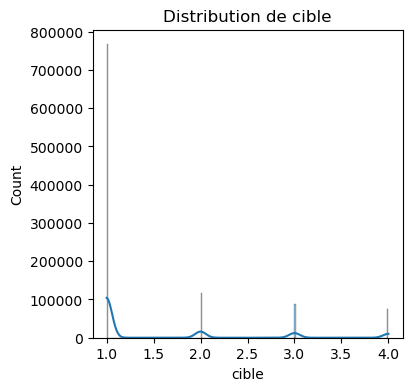

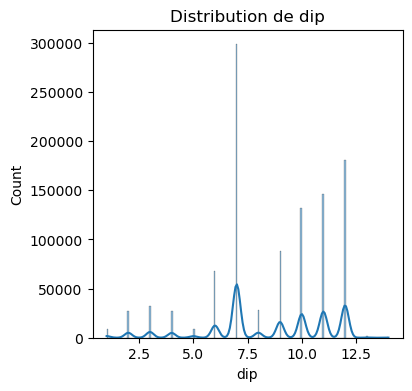

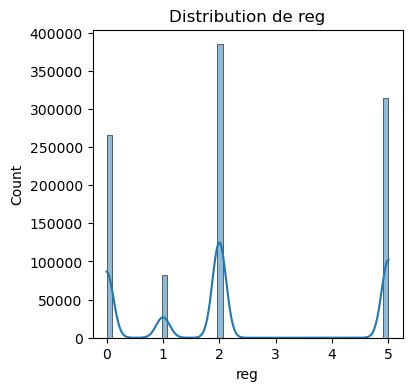

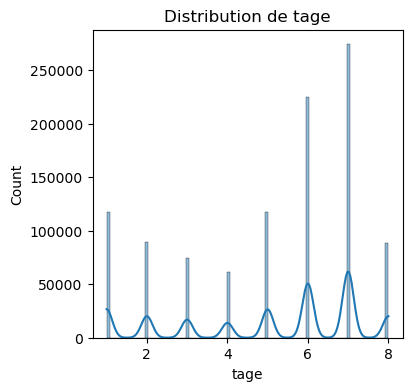

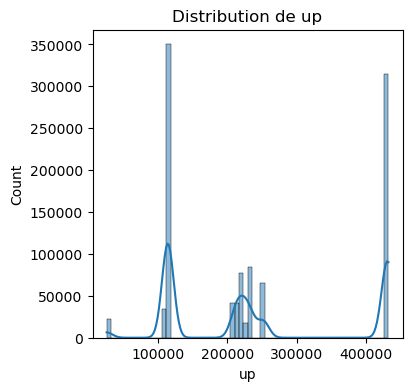

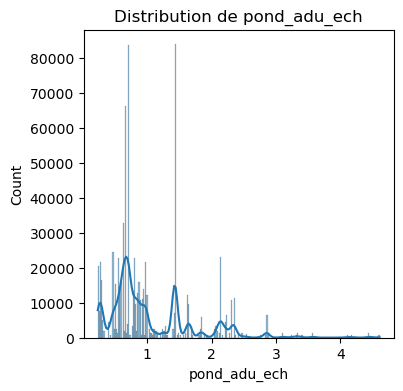

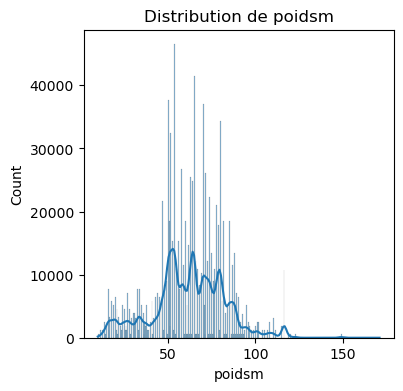

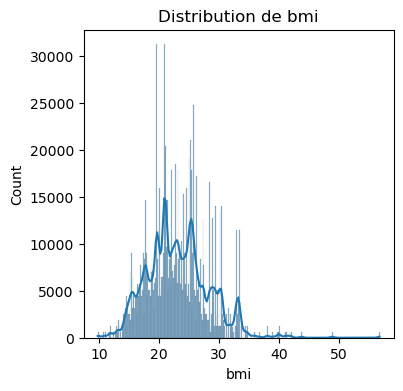

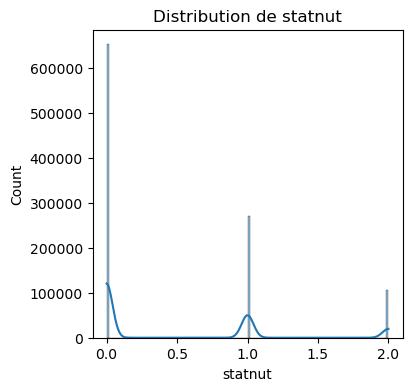

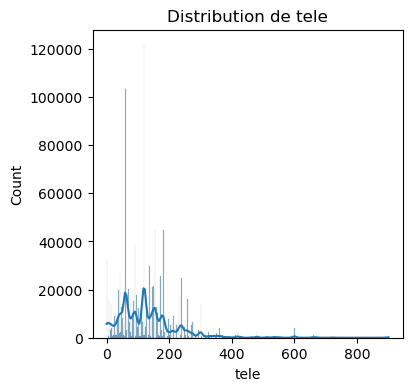

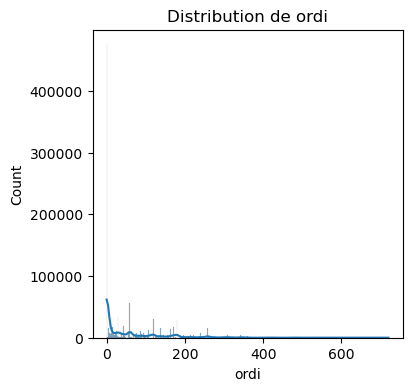

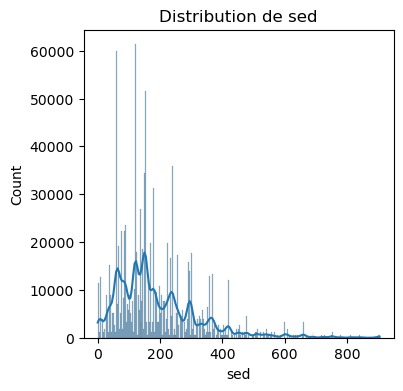

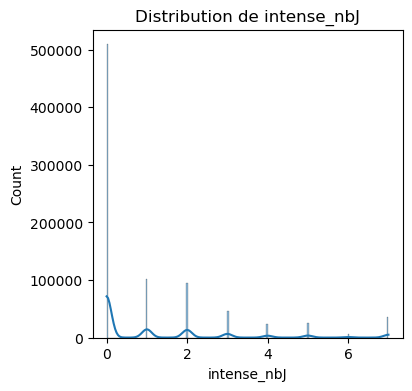

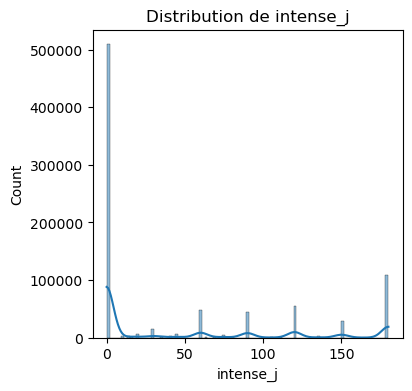

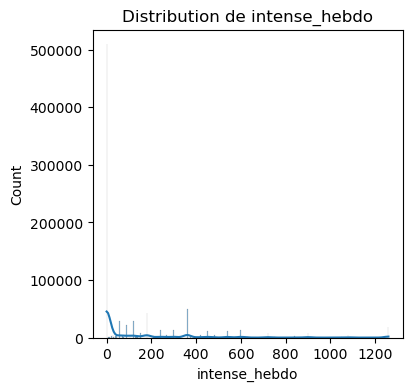

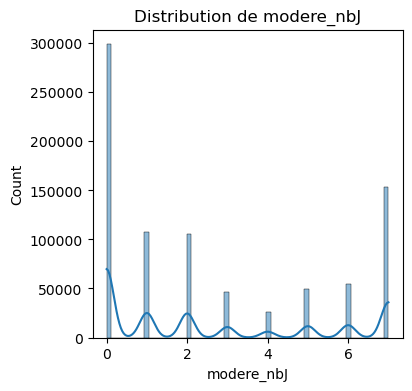

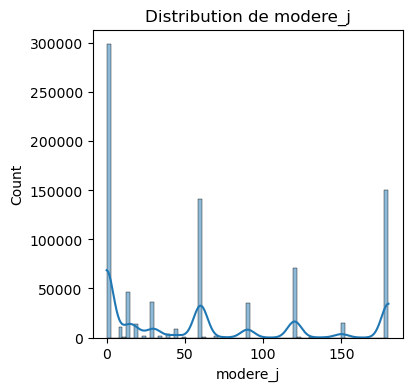

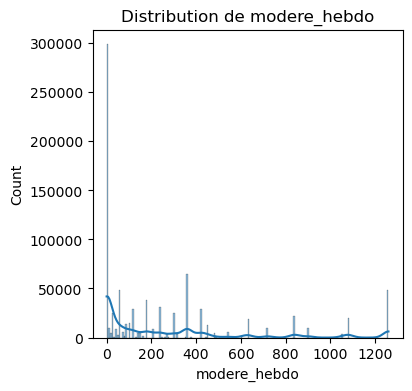

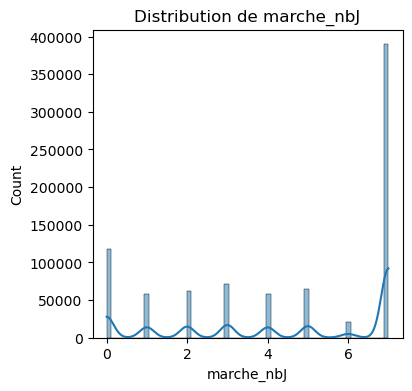

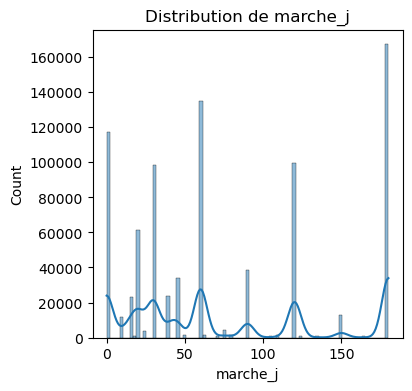

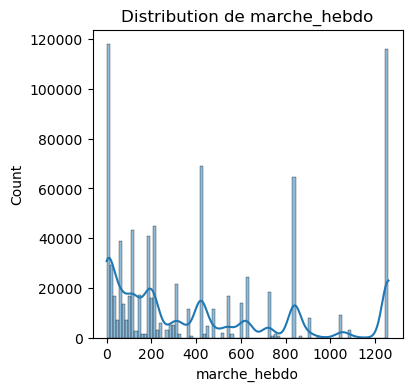

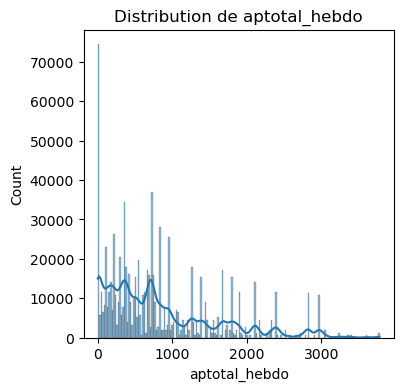

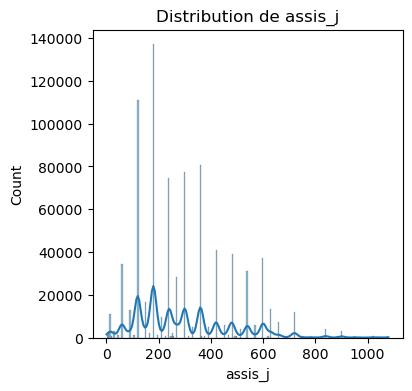

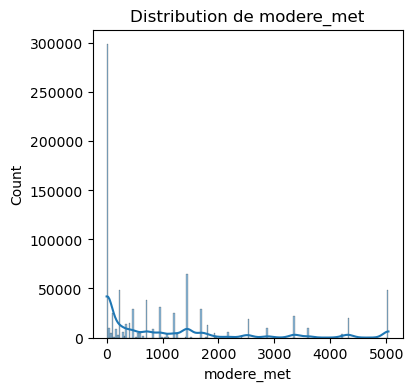

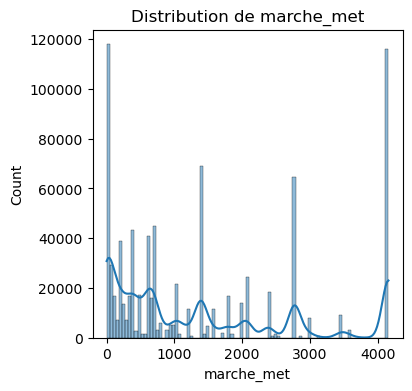

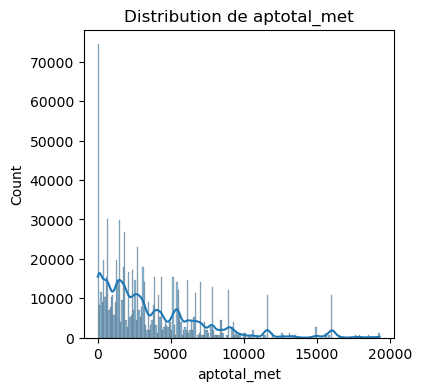

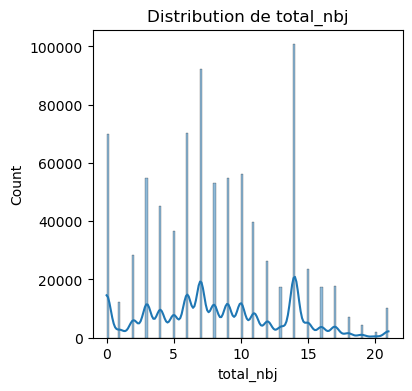

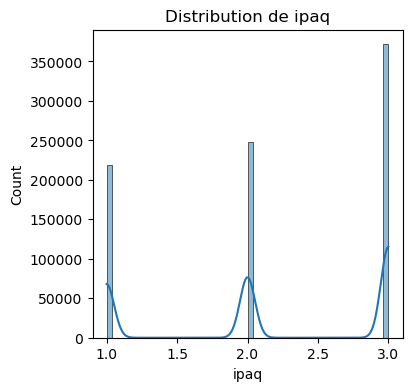

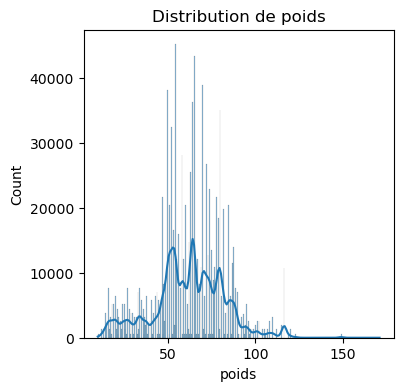

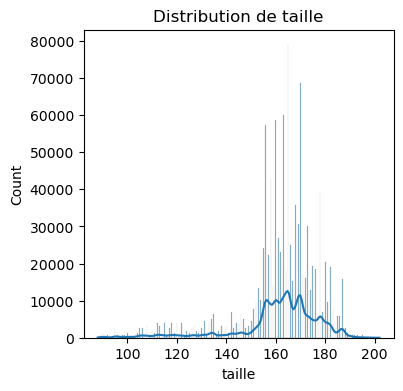

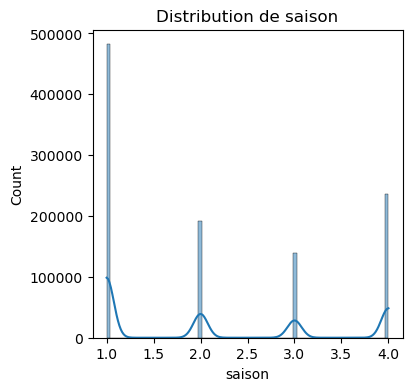

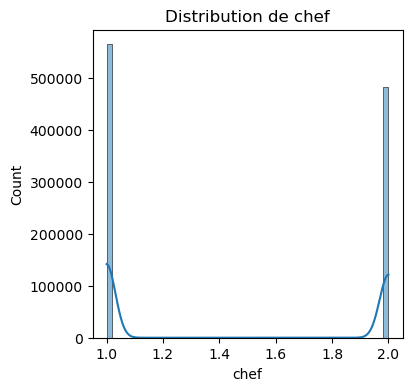

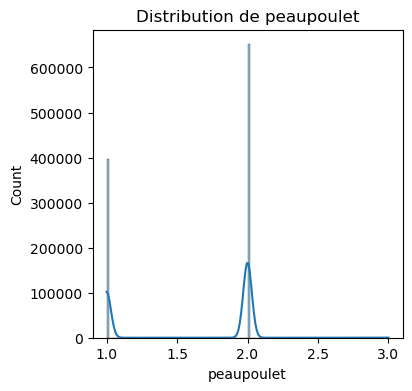

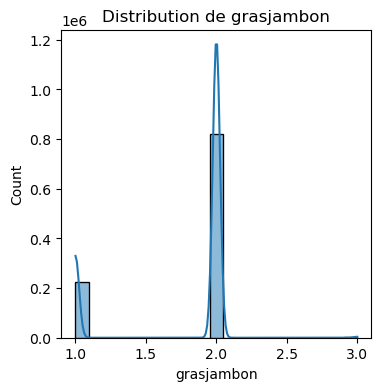

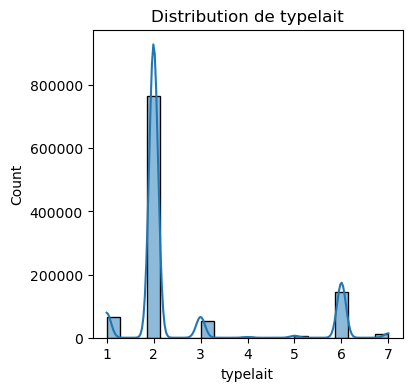

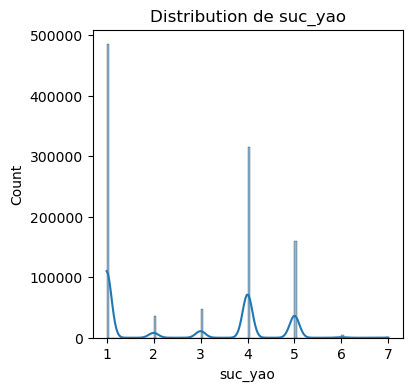

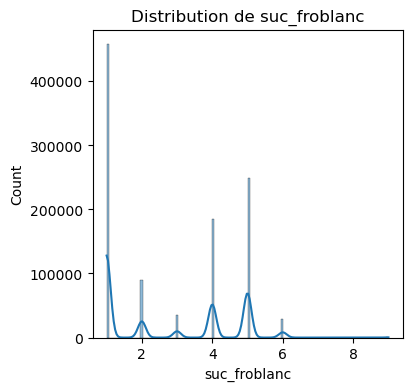

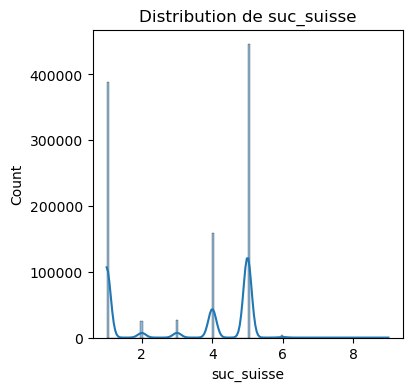

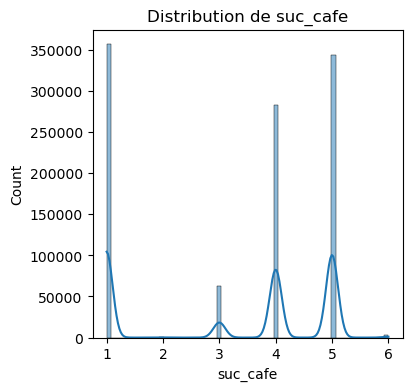

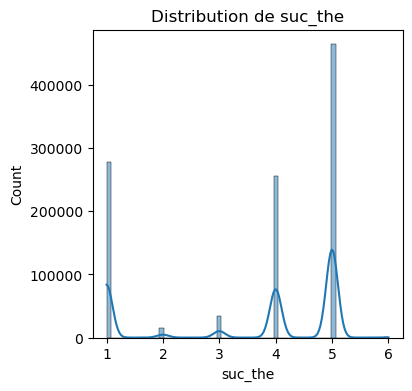

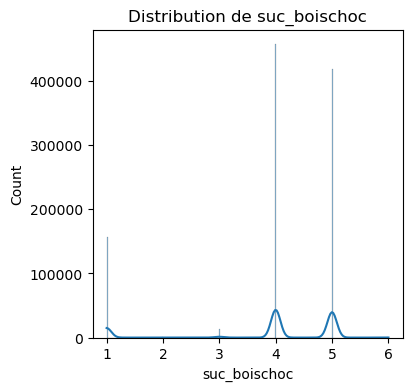

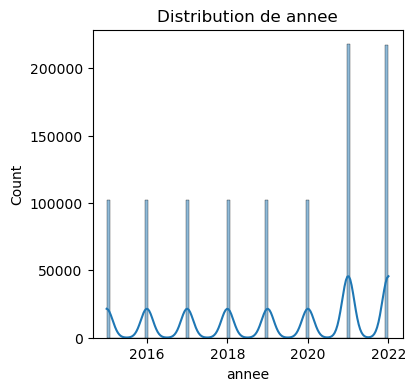

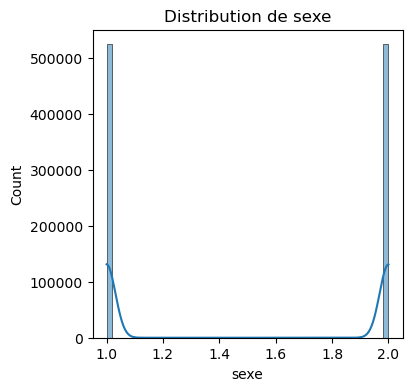

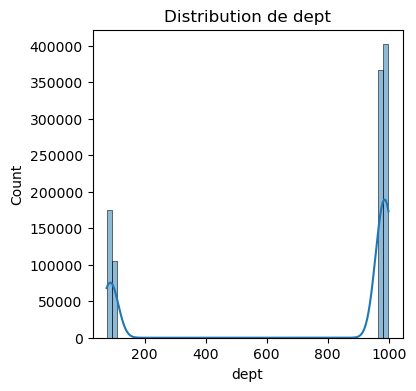

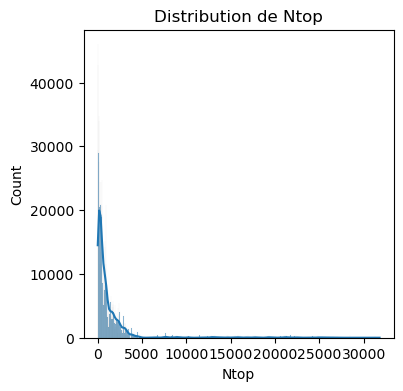

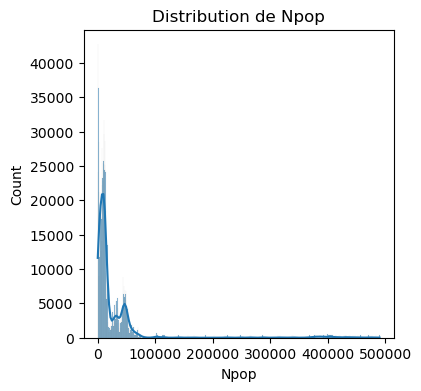

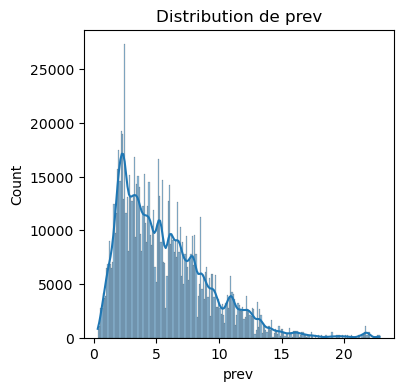

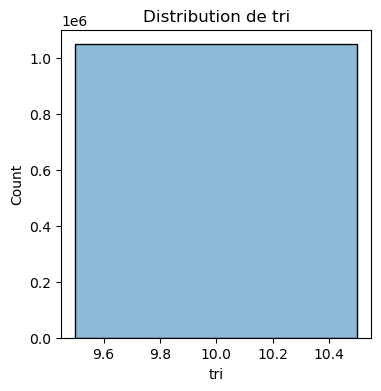

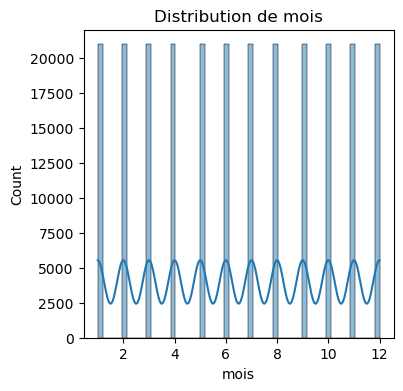

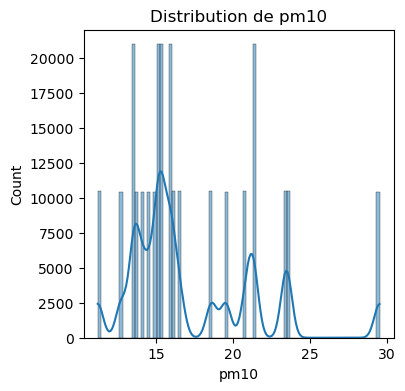

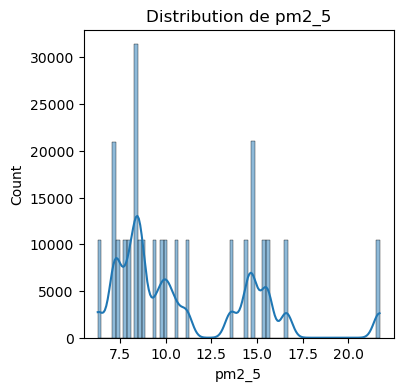

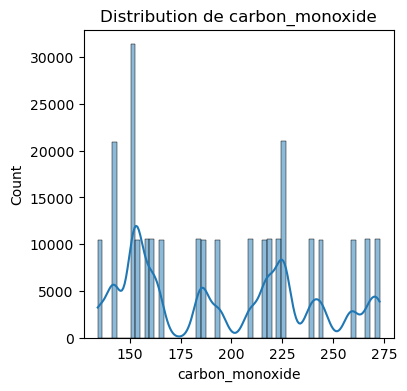

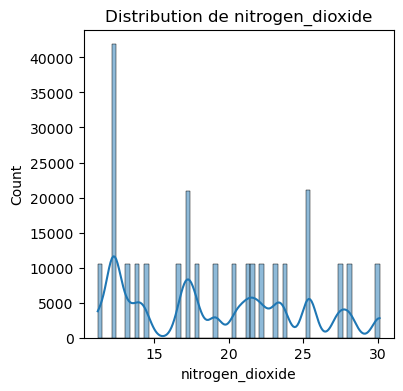

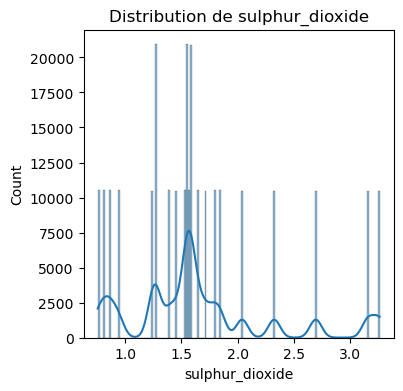

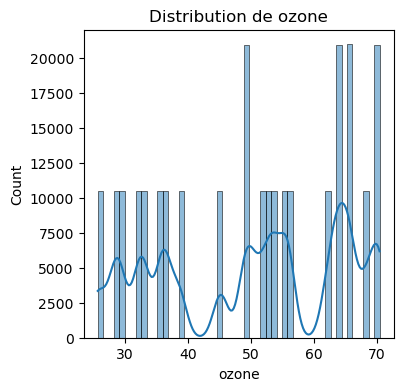

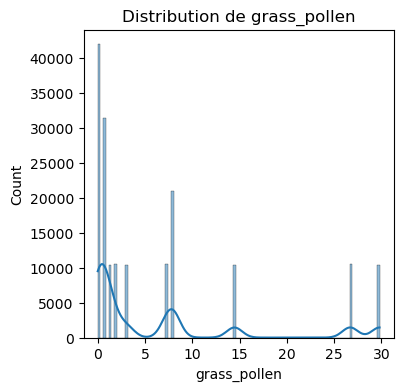

In [26]:
# Sélectionner les colonnes de type 'float' ou 'int'
for col in df.select_dtypes(include=['float64', 'int64']):
    plt.figure(figsize=(4, 4))  # Pour définir la taille de chaque graphique
    sns.histplot(df[col], kde=True)  # Histogramme avec courbe de densité (kde=True)
    
    # Ajouter un titre
    plt.title(f'Distribution de {col}')
    
    # Afficher le graphique
    plt.show()



A travers ces graphiques qui décrivent la distribution des variables continues, nous distinguons plusieurs variables avec une très faible distribution  qui peuvent selon les cas soit faire l'objet de regroupements avec d'autres variables ou de suppressions.
d'autres variables nous indiquent une catégorisations dans leur distribution, le retour à la fiche descriptive de notre dataset nous confirme que pour plusieurs variables il ya des catégories de réponses.

### Visualisation des données catégorielles


In [32]:
#Afficher les colonnes catégorielles et leurs valeurs uniques
for col in df.select_dtypes('object'):
    print(f'{col :-<50} {df[col].unique()}')

acolmat1------------------------------------------ ['Un fruit' nan 'Une viennoiserie (croissant)' 'Fruit' 'Th '
 'Baguette 30 g jambon blanc 40g' 'Biscuit' 'Banane' 'Caf ' 'Croissant'
 'Chouquette' 'Carr  chocolat' 'Pomme' 'Pain' 'Pain au chocolat'
 'Laitages : yaourt' 'Charcuterie' 'Demi baguette' 'Biscuits'
 'Petit g teau' 'Jus de fruit' 'Pain viennois' '1 bonbon (sucette)' 'kiwi'
 'G teaux- biscuits' 'Pain 1/6 baguette' 'G teaux secs' 'Mars 233 f'
 'G teau' 'Sucette' 'G teau au yaourt' 'Barres de c r ales' 'Yaourts'
 '1 morceau de pain' 'Yaourt maigre sans sucre' 'Bonbon' 'G teaux'
 'Pommes' 'Biscotte' 'Viennoiserie (mini croissant' '1 fruit'
 'G teaux (biscuits di t tiques)' 'Yaourt' 'Croissant beurre'
 'Fruit (banane-kiwi)' 'Pomme(s) avec la peau' 'Confiseries'
 'Une boisson (Ricor )' 'Lait' '1 barre au c r ale' 'Baguette'
 'Pain c r ales beurre lait choc' 'Croissant au beurre'
 '1 pomme avec la peau' 'Madeleines' 'Fruits secs' 'Dates' 'Des fruits'
 'Petits g teaux' 'Barre chocola

# Etude de la relation de la target (Ntop) avec le reste des variables

Ntop représente le nombre de patients atteints par des maladies respiratoires chroniques par région.

## Représentation de la target 'Ntop'

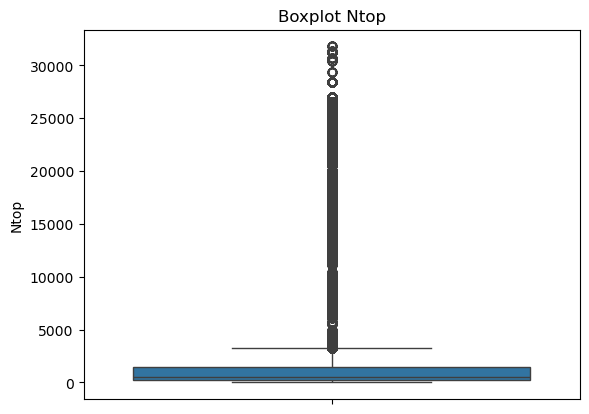

In [37]:
sns.boxplot(y=df['Ntop'])  
plt.title('Boxplot Ntop')
plt.show()

À travers ce boxplot, nous observons la présence de valeurs aberrantes dans la variable cible 'Ntop'. Les opérations suivantes ont pour objectif de supprimer ces valeurs afin d'obtenir des analyses plus précises et fiables.

In [39]:
# Calculer l'IQR pour 'Ntop'
Q1 = df['Ntop'].quantile(0.25)
Q3 = df['Ntop'].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)

# Identifier et éliminer les valeurs aberrantes
df = df[~((df['Ntop'] < (Q1 - 1.5 * IQR)) | (df['Ntop'] > (Q3 + 1.5 * IQR)))]

# Afficher le dataframe nettoyé
print(df)



Q1: 200.0 Q3: 1430.0 IQR: 1230.0
         sexeps  fqcantine  entrerep  colmata  distconf  distfruit  distsoli  \
0           2.0        9.0       4.0      4.0       NaN        NaN       NaN   
1           2.0        9.0       4.0      4.0       NaN        NaN       NaN   
2           2.0        9.0       4.0      4.0       NaN        NaN       NaN   
3           2.0        9.0       4.0      4.0       NaN        NaN       NaN   
4           2.0        9.0       4.0      4.0       NaN        NaN       NaN   
...         ...        ...       ...      ...       ...        ...       ...   
1048570     2.0        9.0       6.0      NaN       NaN        NaN       NaN   
1048571     2.0        9.0       6.0      NaN       NaN        NaN       NaN   
1048572     2.0        9.0       6.0      NaN       NaN        NaN       NaN   
1048573     2.0        9.0       6.0      NaN       NaN        NaN       NaN   
1048574     2.0        9.0       6.0      NaN       NaN        NaN       NaN   

      

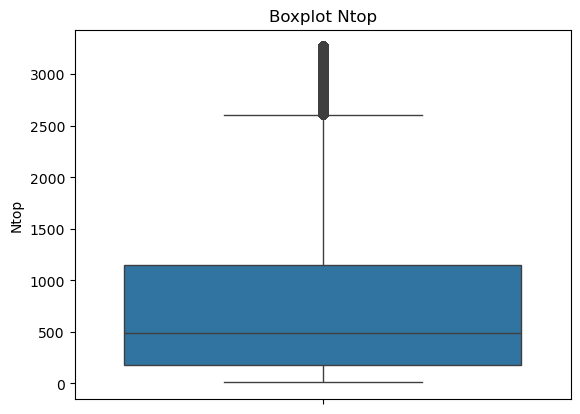

In [40]:
sns.boxplot(y=df['Ntop'])  
plt.title('Boxplot Ntop')
plt.show()

Ce Boxplot représente la variable Target 'Ntop' après la suppression des valeurs abberantes.

Avant de présenter le graphique définissant le lien entre target et classe d'ages, une transformation sur la classe d'age a du être réalisée 
pour inclure les deux classes dans le graphique ("05-09" représentée par "05-sept") et ("10-14" représentée par "oct-14").

In [43]:
print(df['cla_age_5'])

0           00-04
1           00-04
2           00-04
3          oct-14
4          oct-14
            ...  
1048570     35-39
1048571     35-39
1048572     35-39
1048573     35-39
1048574     35-39
Name: cla_age_5, Length: 989909, dtype: object


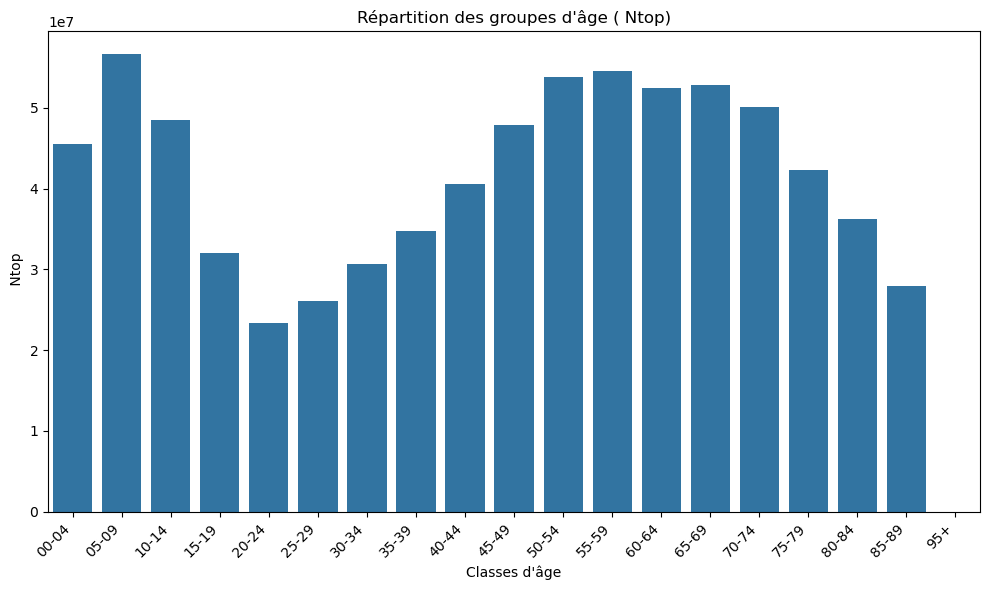

In [45]:
#modifier l'affichage des valeurs erronées
df.loc[df['cla_age_5'] == '05-sept', 'cla_age_5'] = "05-09"
df.loc[df['cla_age_5'] == 'oct-14', 'cla_age_5'] = "10-14"

# Définir l'ordre des groupes d'âge
age_order = ['00-04', '05-09', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89','95+']

# Nettoyer ou harmoniser les valeurs de 'cla_age_5'
df['cla_age_5'] = df['cla_age_5'].str.strip()

# Convertir 'cla_age_5' en catégorie ordonnée selon 'age_order'
df['cla_age_5'] = pd.Categorical(df['cla_age_5'], categories=age_order, ordered=True)

# Grouper par 'cla_age_5' et sommer les valeurs de Ntop pour chaque groupe d'âge
age_counts = df.groupby('cla_age_5', observed=False)['Ntop'].sum().sort_index()

# Créer un graphique en barres avec Seaborn
plt.figure(figsize=(10, 6))  # Ajuster la taille du graphique
sns.barplot(x=age_counts.index, y=age_counts.values)

# Ajouter des titres
plt.title("Répartition des groupes d'âge ( Ntop)")
plt.xlabel("Classes d'âge")
plt.ylabel(" Ntop")

# Améliorer l'affichage des étiquettes sur l'axe des x
plt.xticks(rotation=45, ha='right')  # Rotation des étiquettes pour améliorer la lisibilité

# Afficher le graphique
plt.tight_layout()  # Ajuster l'espacement pour éviter que le texte ne se chevauche
plt.show()



### Relation entre Target/ Région

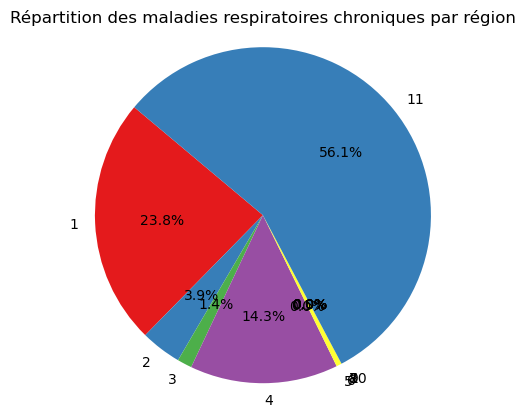

In [47]:
# grouper par région en sommant sur Ntop
region_data = df.groupby('region', observed=False)['Ntop'].sum()

# Créer une palette de couleurs (par exemple, "Set1" de Seaborn)
colors = sns.color_palette("Set1", len(region_data))

# Ajuster la taille du graphique et ajouter des couleurs
plt.pie(region_data, labels=region_data.index, autopct='%1.1f%%', startangle=140, colors=colors)

# Ajouter un titre
plt.title("Répartition des maladies respiratoires chroniques par région")

# Afficher le graphique
plt.axis('equal')  # Assurer que le camembert soit circulaire
plt.show()


### Relation entre Target/ sexe

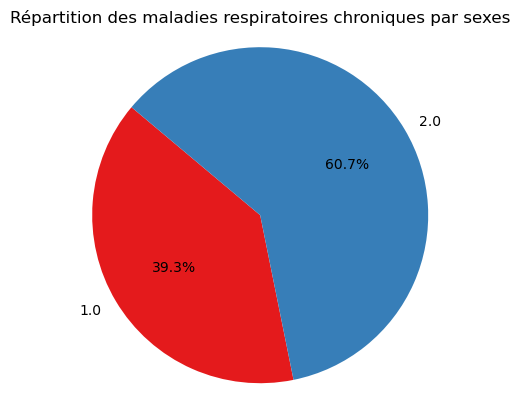

In [49]:
sexeps_count=df.groupby('sexeps', observed=False)['Ntop'].count()

# Créer une palette de couleurs (par exemple, "Set1" de Seaborn)
colors = sns.color_palette("Set1", len(region_data))

# Ajuster la taille du graphique et ajouter des couleurs
plt.pie(sexeps_count, labels=sexeps_count.index, autopct='%1.1f%%', startangle=140, colors=colors)

# Ajouter un titre
plt.title("Répartition des maladies respiratoires chroniques par sexes")

# Afficher le graphique
plt.axis('equal')  # Assurer que le camembert soit circulaire
plt.show()

Cette distribution nous indique que les femmes(2) sont plus atteintes par les maladies respiratoires chroniques que les hommes.

### Relation entre Target/ qualité de l'air 

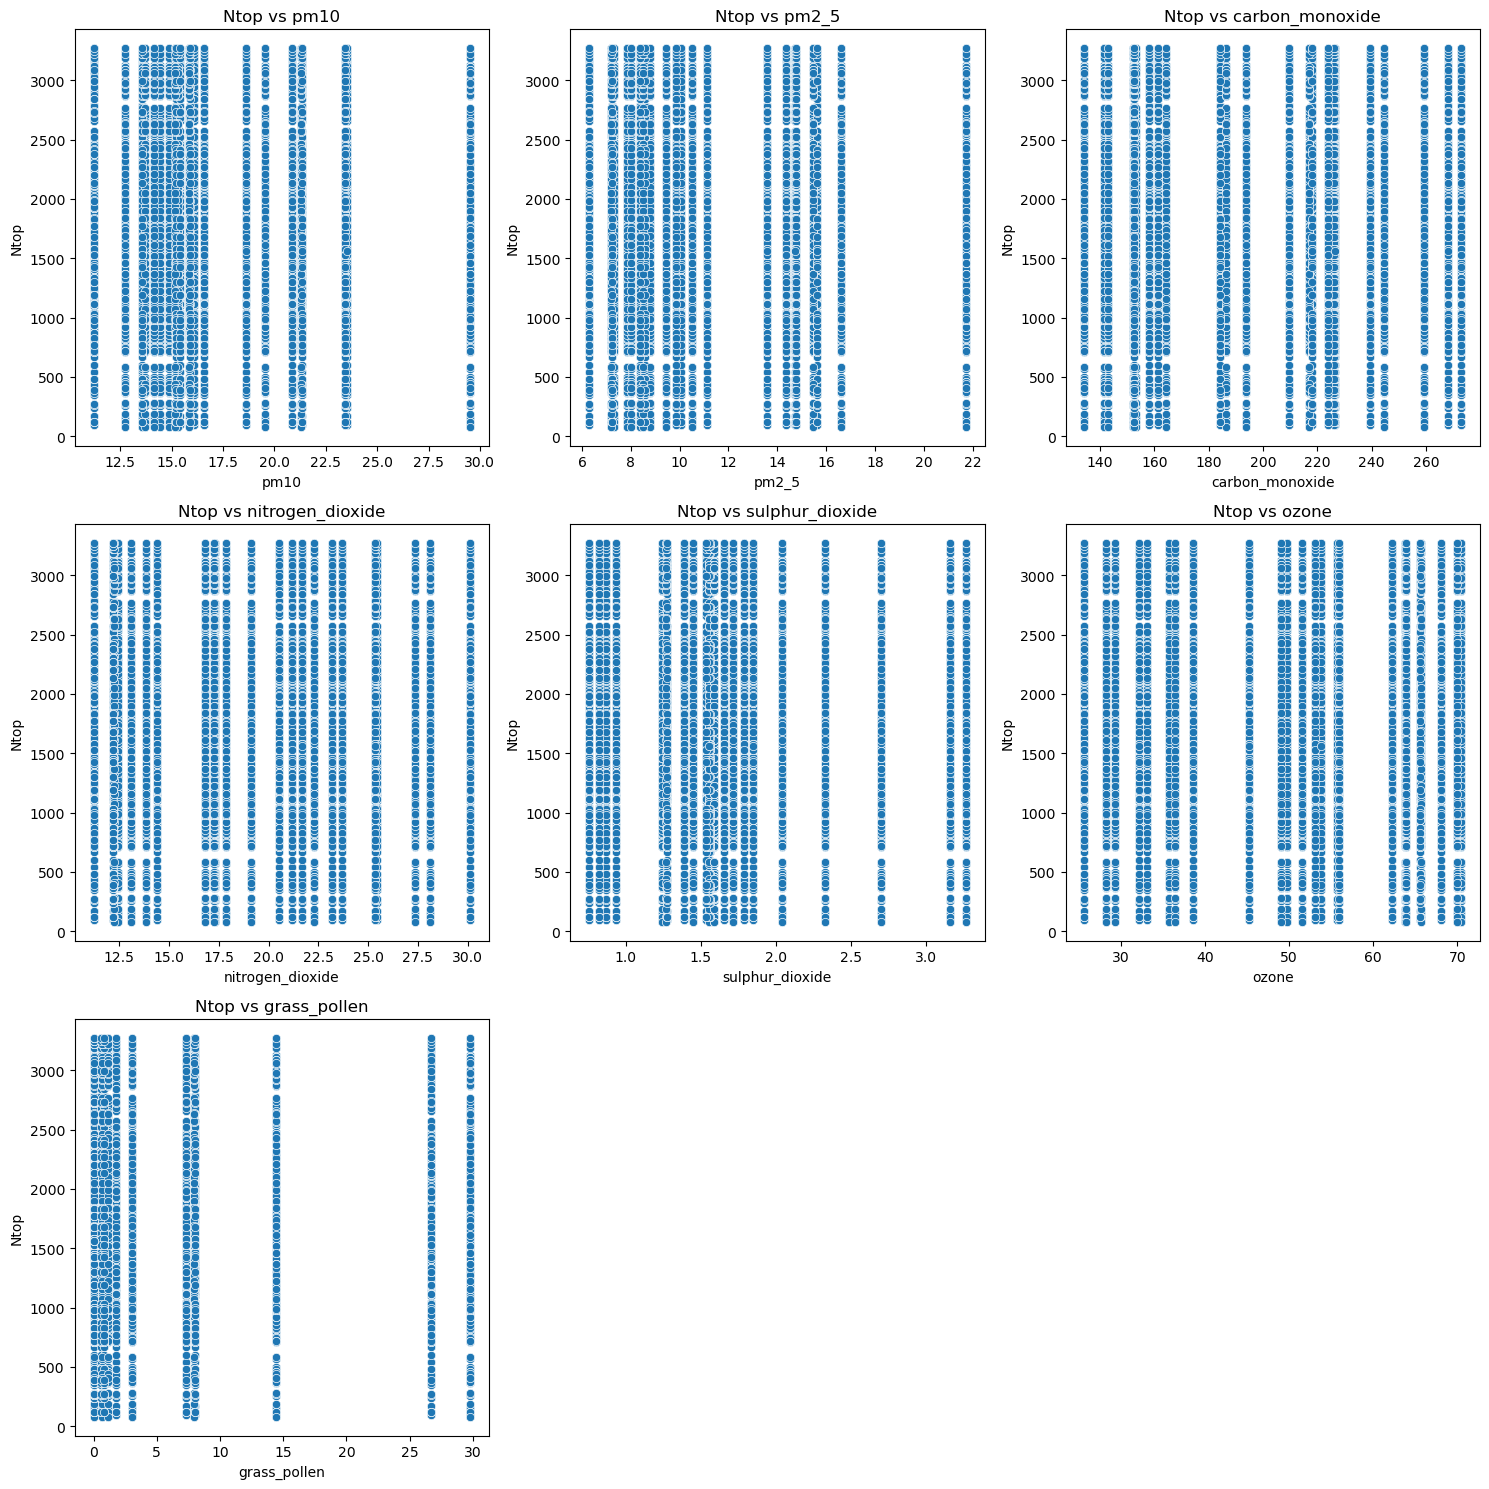

In [57]:

# Liste des colonnes à utiliser pour les subplots
columns = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'grass_pollen']

# Définir le nombre de lignes et de colonnes pour les subplots
n_cols = 3  # Nombre de colonnes
n_rows = (len(columns) + n_cols - 1) // n_cols  # Calcul du nombre de lignes

# Créer une figure avec des subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Applatir les axes pour un accès facile
axes = axes.flatten()

# Créer un subplot pour chaque variable
for i, col in enumerate(columns):
    sns.scatterplot(x=df[col], y=df['Ntop'], ax=axes[i])
    axes[i].set_title(f'Ntop vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Ntop')

# Supprimer les axes inutilisés si il y en a
for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])

# Ajuster l'espacement entre les subplots
plt.tight_layout()
plt.show()


Cette distribution des indicateurs de la qualité de l'air ne nous permet pas de déduire une coorélation entre Ntop (le nombre de malades respiratoires) et la qualité de l'air. Ce type de distributions nécessite une étude plus approfondie puisqu'il peut supposer l'absence de lien comme il peut s'expliquer par des similarité de distribution de Ntop par rapport aux indicateurs de la qualité de l'air ou encore que Ntop prends des valeurs limitées.

# 2- Pré-traitements des données

## Nettoyage et transformation des données

Suite à l'analyse des données nous avons repérés des modifications à réaliser visant à améliorer leur exploitation dans la prédiction de l'évolution des maladies respiratoires chroniques. Ces transformations sont essentiellement:
-Des suppressions de colonnes (dupliquées) ou ayant une même signification.
- Des regroupement de données complémentaire (exemple des apports en sucre à cumuler sur la durée d'une semaine).
- Des imputations de valeurs manquantes.


# Regroupements de données

In [53]:
## Regroupement des variables liées au type de sucre consommé en une variable binaire:

In [54]:
import numpy as np

df['conso_sucre'] = np.where(
    (df['suc_yao'].isin([1, 2, 3, 7, 9])) | 
    (df['suc_froblanc'].isin([1, 2, 3, 7, 9])) | 
    (df['suc_suisse'].isin([1, 2, 3, 7, 9])) | 
    (df['suc_cafe'].isin([1, 2, 3, 7, 9])) | 
    (df['suc_the'].isin([1, 2, 3, 7, 9])) | 
    (df['suc_boischoc'].isin([1, 2, 3, 7, 9]))|
    (df['suc_the'].isin([1, 2, 3, 7, 9]))
                            ,
    1,  # si l'un des types de sucres est consommé
    0   # aucune consommation de sucre
)


In [55]:
# suppression des colonnes après calcul et regroupement
df = df.drop(['conso_sucre', 'suc_yao', 'suc_froblanc', 'suc_suisse', 'suc_cafe', 'suc_boischoc','suc_the'], axis=1, errors='ignore')


## Regroupement des variables liées à la fréquence des entre-repas:

In [57]:
df['entrerep'] = df['entrerep'] + df['colmata']
df.drop(['colmata'], axis=1, errors='ignore')

,sexeps,fqcantine,entrerep,distconf,distfruit,distsoli,fastfood,selassent,selassleg,selassfec,...,libelle_sexe,tri,mois,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,grass_pollen
0,2.0,9.0,8.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,...,hommes,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,9.0,8.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,...,hommes,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,9.0,8.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,...,femmes,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,9.0,8.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,...,hommes,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.0,9.0,8.0,NaN,NaN,NaN,6.0,1.0,1.0,1.0,...,femmes,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2.0,9.0,NaN,NaN,NaN,NaN,5.0,3.0,2.0,3.0,...,femmes,10.0,11.0,20.839444,14.370000,272.903222,30.134667,1.652222,25.678444,NaN
1048571,2.0,9.0,NaN,NaN,NaN,NaN,5.0,3.0,2.0,3.0,...,femmes,10.0,12.0,15.913118,11.141290,239.189247,23.673548,1.532796,33.063871,NaN
1048572,2.0,9.0,NaN,NaN,NaN,NaN,5.0,3.0,2.0,3.0,...,femmes,10.0,1.0,18.611290,14.717204,268.191828,25.451075,1.847419,32.129032,0.000000
1048573,2.0,9.0,NaN,NaN,NaN,NaN,5.0,3.0,2.0,3.0,...,femmes,10.0,2.0,21.332143,13.584167,226.335238,21.690476,1.561548,45.208690,0.000000


## Regroupement des variables liées à la consommation de sel en une variable binaire

In [59]:
df['ajout_sel'] = np.where(
    (df['selassent'].isin([1, 2, 3,4])) | 
    (df['selassleg'].isin([1, 2, 3,4])) | 
    (df['selassfec'].isin([1, 2, 3,4])) | 
    (df['selassvp'].isin([1, 2, 3,4])) | 
    (df['selassvps'].isin([1, 2, 3,4])) | 
    (df['selassoeuf'].isin([1, 2, 3,4])),
    1,  # s'il y a ajout de sel dans les repas
    0   # pas d'ajout de sel
)

In [60]:
# suppression des colonnes après calcul et regroupement
df = df.drop(['selassent', 'selassleg', 'selassfec', 'selassvp', 'selassvps', 'selassoeuf','colmata'], axis=1, errors='ignore')

## Regroupement des variables liées à la consommation de proteines animales

In [62]:

select_columns = ["boeufcru", "chevcru", "porccru", "volcru", "poiscru", "oeufcru",
                "shboeufcuis", "boeufcuis", "rotboeufcuis", "foiecuis", "veaucuis",
                "porccuis", "sauccuis", "chevcuis", "agncuis", "volcuis","lardcru","sauccru"]
df["p_animal"] = df[select_columns].sum(axis=1)
 
# Suppression des colonne
df.drop(columns=select_columns, inplace=True)

## Regroupement des variables liées à la consommation de proteines végétales

In [64]:
df["p_vegetale"] = df[["fqfec", "fqfl"]].sum(axis=1)
 
# Suppression des colonne
df.drop(columns=["fqfec", "fqfl"], inplace=True)

## Regroupement des données sur la consommation de gras animal:

In [66]:
# Créer la nouvelle colonne 'gras_animal' en additionnant 'peaupoulet' et 'grasjambon'
df['gras_animal'] = df['peaupoulet'] + df['grasjambon']

# Supprimer les colonnes 'peaupoulet' et 'grasjambon'
df.drop(['peaupoulet', 'grasjambon'], axis=1, inplace=True)


## Regroupement des données sur les visites_médicales:

In [68]:

df['vistes_medecins'] = df['nbgeneral'] + df['nbspecial']

# Supprimer les colonnes 'peaupoulet' et 'grasjambon'
df.drop(['nbgeneral', 'nbspecial'], axis=1, inplace=True)


## Nombre de cigarettes par semaine ( fumeur)

In [70]:
##### Fréquence
nb_cig_jours = ["nbcigrjm", "nbpipejm", "nbcigtm", "nbcigrja", "nbpipeja", "nbcigta"]
nb_cig_semaine = ["nbpipesm", "nbcigrsm", "nbpipesa", "nbcigrsa"]
 
# Convertir par semaine
convert_to_semaine = df[nb_cig_jours].mul(7)
 
# Sélectionner les colonnes pour la semaine
semaine_df = df[nb_cig_semaine]
 
# Concaténer et calculer la moyenne
df["fumeur"] = pd.concat([convert_to_semaine, semaine_df], axis=1).mean(axis=1)
 
# Suppression des colonne
drop_cols = nb_cig_jours + nb_cig_semaine
df.drop(columns=drop_cols, inplace=True)
 

## Calcul et regroupement des données sur la sédentarité en heure par semaine 

In [72]:
# --------------- Sédentarité (jours => semaines 'heures') --------------------
df["sedentaire"] = df[["tele", "ordi", "sed",'assis_j']].mean(axis=1)*7/60
df.drop(columns=["tele", "ordi", "sed",'assis_j'], inplace=True)
 

## Régime spécial

In [74]:
 
# --------------- Régime spécial --------------------
select_columns = ["regimem", "regimedj", "regvegr", "regvegt", "regrelig",
                "regmedic", "regform", "regstab", "regmaig", "regaut"]
df["regime_special"] = df[select_columns].sum(axis=1)
 
# Suppression des colonne
df.drop(columns=select_columns, inplace=True)

## Achats aux distributeurs:

In [76]:
select_distr = ["distconf","distfruit","distsoli","disteaum","distsoda","distjus","distbar","distgat","distbiss","distaut"] 
df["achats_distributeurs"] = df[select_distr].sum(axis=1)
 
# Suppression des colonne
df.drop(columns=select_distr, inplace=True)
 

## Activité physique  en heure par semaine:

l'activité physique a été décrite de trois façons différentes (en minutes, par jours et par mètres), ce qui implique des répétitions dans le dataset.Pour ce faire nous avons opté pour le regroupement, calcul de moyenne puis conversion en heures par semaine et la suppresssion des valeurs en trop.

In [79]:
df.columns = df.columns.str.strip() 
df['temps_act_phy'] = df[['intense_hebdo', 'modere_hebdo', 'marche_hebdo', 'aptotal_hebdo']].mean(axis=1) * 7 / 60
print(df['temps_act_phy'])

0          39.375
1          39.375
2          39.375
3          39.375
4          39.375
            ...  
1048570     0.000
1048571     0.000
1048572     0.000
1048573     0.000
1048574     0.000
Name: temps_act_phy, Length: 989909, dtype: float64


In [80]:
# Suppression des colonnes avec des valeurs répétitives
df = df.drop(['intense_nbJ', 'modere_nbJ', 'marche_nbJ', 'intense_hebdo', 'modere_hebdo', 
              'marche_hebdo', 'intense_j', 'modere_j', 'marche_j', 'modere_met', 'marche_met', 
              'aptotal_met', 'total_nbj','aptotal_hebdo','act_phy'], axis=1, errors='ignore')


## Calcul de la moyenne des poids:

In [82]:
# Liste des colonnes contenant les données sur le poids
data_poids = ['poids12', 'pdsmax', 'pdsmin', 'poidsm', 'poids']

# Remplacer les valeurs 998 et 999 par 99 dans les colonnes concernées
df[data_poids] = df[data_poids].replace({998: 99, 999: 99})

# Calculer la moyenne des colonnes 
df['poids_moyen'] = df[data_poids].mean(axis=1)

# Suppression des colonnes de poids originales
df.drop(columns=data_poids, inplace=True)

# Les Suppressions

## Suppression des colonnes répétitives 

In [85]:
df = df.drop(['libelle_sexe', 'niveau_prioritaire', 'sexe', 'top', 'chef', 'up', 'tage', 'v2_age', 'cible','tri','v2_age','cible','pond_adu_ech','q148','lieudej','clage','lieudej','loc_log','lien_int_chef','nrentr','nrcont','pdsmaxnsp','moisgross','nbpipemnsp','nrentr','contap','agepmin','nrreg','nrcont','pdsmaxnsp','moisgross','nbpipemnsp','nrentr','v2_nbenf','reg','Niveau prioritaire','acolmat1_cod','acolmat2_cod','acolmat3_cod','acolmat4_cod','nbpipemnsp','enceinte12'], axis=1, errors='ignore')


## Suppression des variables ayant une majorité de valeurs nulles visibles sur le graphique:

In [87]:
df = df.drop(['moisgrossnsp', 'nbcigrmnsp', 'agefumemnsp','nbcigransp','nbpipeansp','nbpipeansp','nbpipeansp','cantsant','colmatecol','fqcigta','agefumea','agefumeansp','agestop','agestopnsp','fqcigtm'], axis=1, errors='ignore')

## Suppression des variables liées aux avis des consommateurs:


In [89]:
df = df.drop(['infoami', 'infoaut', 'intaliaut','intalicuisi', 'intalifabr','intaliform','intaliplais','intaliregi','acolmat1','acolmat2','acolmat3','acolmat4'], axis=1, errors='ignore')

# Imputations des valeurs manquantes

## Imputation des valeurs de entrerep ( fréquence des entre-repas:)

In [92]:
from sklearn.impute import SimpleImputer

# Créer l'objet SimpleImputer avec la stratégie 'most_frequent'
simple_most = SimpleImputer(strategy='most_frequent')

# Appliquer l'imputation à la colonne 'entrerep' et remplacer les valeurs manquantes
df['entrerep'] = simple_most.fit_transform(df[['entrerep']])



## Vérification des valeurs manquantes

In [94]:
# Calcul du pourcentage des valeurs manquantes par colonne
pourcentage_colonne = (df.isnull().sum() / df.shape[0]) * 100

# Afficher le pourcentage des valeurs manquantes
print(pourcentage_colonne)


sexeps                  28.614246
fqcantine                0.323464
entrerep                 0.000000
fastfood                 0.323464
enrich                   0.323464
                          ...    
sedentaire               0.064652
regime_special           0.000000
achats_distributeurs     0.000000
temps_act_phy           20.814843
poids_moyen              0.000000
Length: 64, dtype: float64


## Imputation des valeurs manquantes des valeurs catégorielles (sexeps) et des classes de valeurs:

La stratégié d'imputation pour laquelle on a opté pour l'imputation des valeurs manquantes est celle du remplacement des "nan" par les valeurs les plus fréquentes dans les colonnes "sexeps" et "contap" (contrôle son poids par l'activité physique).

In [97]:
from sklearn.impute import SimpleImputer

df.columns = df.columns.str.strip() 
# Création de l'imputer avec la stratégie 'most_frequent'
Imputer_freq = SimpleImputer(strategy='most_frequent')

# Sélectionner les colonnes à imputer
data_freq = df[['sexeps', 'ajout_sel', 'heur_trav', 'trav_nuit', 'ths', 'acolmat1_gr', 'acolmat2_gr', 'acolmat3_gr', 'acolmat4_gr', 'contmed','ipaq','dlcpl','fqvpo','fqpl','typ_empl','stat_empl','statnut', 'cla_age_5', 'dept','fqcantine','fastfood', 'enrich','agefumem','fume','annee','mois','contsubt','vistes_medecins']]

# Appliquer l'imputation sur les colonnes sélectionnées
df[['sexeps', 'ajout_sel', 'heur_trav', 'trav_nuit', 'ths', 'acolmat1_gr', 'acolmat2_gr', 'acolmat3_gr', 'acolmat4_gr', 'contmed','ipaq','dlcpl','fqvpo','fqpl','typ_empl','stat_empl','statnut', 'cla_age_5', 'dept','fqcantine','fastfood', 'enrich','agefumem','fume','annee','mois','contsubt','vistes_medecins']] = Imputer_freq.fit_transform(data_freq)

# Afficher le DataFrame après transformation
print(df)



        sexeps fqcantine  entrerep fastfood enrich  cyclepds  enceinte  \
0          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
1          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
2          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
3          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
4          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
...        ...       ...       ...      ...    ...       ...       ...   
1048570    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048571    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048572    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048573    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048574    2.0       9.0       8.0      5.0    3.0       5.0       2.0   

         allaite  menopaus  ths  ... p_animal p_vegetale gras_animal  \
0            2.0       1.0  2.0  ...   

## Imputation des valeurs manquantes par les moyennes pour les données numériques continues:

In [99]:
from sklearn.impute import SimpleImputer
df.columns = df.columns.str.strip() 
# Sélection des colonnes numériques
data_numerique = df[['sedentaire', 'temps_act_phy']]

# Création de l'imputer avec la stratégie 'mean' (moyenne)
imputer_mean = SimpleImputer(strategy='mean')

# Appliquer l'imputation par la moyenne sur les colonnes sélectionnées
df[['sedentaire', 'temps_act_phy']] = imputer_mean.fit_transform(data_numerique)



## Imputation des valeurs manquantes par des zeros pour la colonne fumeur et pasreg(pas de régime):

In [101]:
df['fumeur'] = df['fumeur'].fillna(0)
df['pasreg']= df['pasreg'].fillna(0)

##  Imputation des valeurs nulles des variables liées à la santé des femmes par zéro

In [103]:
# Sélectionner les colonnes à traiter
data_femme = df[['enceinte', 'allaite', 'menopaus']]

# Appliquer fillna pour remplacer les valeurs manquantes par 0
df[['enceinte', 'allaite','menopaus']] = data_femme.fillna(0)


## Imputation des valeurs de prev,Ntop et Npop par les valeurs moyennes:

In [105]:
from sklearn.impute import SimpleImputer

# Créer l'imputer SimpleImputer avec la stratégie 'mean'
imputer_mean = SimpleImputer(strategy='mean')

# Sélectionner les colonnes à imputer
data_pop = df[['Ntop', 'prev', 'Npop']]

# Appliquer l'imputation par la moyenne
df[data_pop.columns] = imputer_mean.fit_transform(data_pop)

# Afficher le DataFrame après imputation
print(df)

        sexeps fqcantine  entrerep fastfood enrich  cyclepds  enceinte  \
0          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
1          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
2          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
3          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
4          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
...        ...       ...       ...      ...    ...       ...       ...   
1048570    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048571    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048572    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048573    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048574    2.0       9.0       8.0      5.0    3.0       5.0       2.0   

         allaite  menopaus  ths  ... p_animal p_vegetale gras_animal  \
0            2.0       1.0  2.0  ...   

## Imputation des valeurs manquantes de poids_moyen, cycles de perte et reprise de poids et taille

In [107]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Créer l'imputeur avec la stratégie 'mean'
imputer_mean = SimpleImputer(strategy='mean')

# Appliquer l'imputation par groupe d'âge (cla_age_5)
for group in df['cla_age_5'].unique():  # Pour chaque groupe d'âge unique
    # Sélectionner les lignes de ce groupe
    group_data = df[df['cla_age_5'] == group]
    
    # Appliquer l'imputation sur les colonnes d'intérêt pour ce groupe
    df.loc[df['cla_age_5'] == group, ['poids_moyen', 'cyclepds', 'taille']] = imputer_mean.fit_transform(group_data[['poids_moyen', 'cyclepds', 'taille']])

# Vérification : afficher les premières lignes pour s'assurer que l'imputation a été faite
print(df[['poids_moyen', 'cyclepds', 'taille']].head())
print(df.shape)

   poids_moyen  cyclepds  taille
0         81.6       2.0   162.0
1         81.6       2.0   162.0
2         81.6       2.0   162.0
3         81.6       2.0   162.0
4         81.6       2.0   162.0
(989909, 64)


## Imputation des valeurs de bmi (IMC)

In [109]:
import numpy as np

# Calculer le BMI pour les lignes où 'bmi' est manquant (NaN)
df.loc[df['bmi'].isna(), 'bmi'] = df.loc[df['bmi'].isna(), 'poids_moyen'] / np.square(df.loc[df['bmi'].isna(), 'taille'])

# Vérification : afficher les premières lignes pour s'assurer que les valeurs ont été imputées
print(df[['poids_moyen', 'taille', 'bmi']].head())


   poids_moyen  taille       bmi
0         81.6   162.0  31.24524
1         81.6   162.0  31.24524
2         81.6   162.0  31.24524
3         81.6   162.0  31.24524
4         81.6   162.0  31.24524


## Imputation des valeurs de la qualité de l'air 


Pour Imputer les valeurs manquantes de la qualité de l'air, on procede par étapes :
Durant la première nous faison l'imputation en regroupant les données par région, mois et année et en appliquant la moyenne du groupe.
Dans la deuxième étape nous considérons les groups avec une totalité de valeurs nulles trouvées durant la première étape pour les imputer de la moyenne sans regroupements?

### Etape1

In [113]:
from sklearn.impute import SimpleImputer

# Liste des colonnes à imputer
data_air = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'grass_pollen']

# Créer l'objet SimpleImputer avec la stratégie 'median'
imputer_simple_air = SimpleImputer(strategy='median')


# Créer un DataFrame vide pour les résultats imputés
df_imputed = df.copy()

# Grouper les données par 'region', 'mois', et 'annee'
df_grouped = df_imputed.groupby(['region', 'mois', 'annee'])

# Appliquer l'imputation SimpleImputer pour chaque groupe
for group, group_data in df_grouped:
    # Appliquer l'imputation uniquement si le groupe contient des données manquantes
    if group_data[data_air].isnull().any().any():
        # Séparer les colonnes avec toutes les valeurs manquantes
        cols_with_all_missing = group_data[data_air].columns[group_data[data_air].isnull().all()]
        cols_with_some_values = group_data[data_air].columns.difference(cols_with_all_missing)
        
        # Appliquer l'imputation sur les colonnes avec des valeurs observées
        if not cols_with_some_values.empty:
            transformed_values = imputer_simple_air.fit_transform(group_data[cols_with_some_values])
            
            # Vérification : transformed_values doit avoir les mêmes dimensions que group_data[cols_with_some_values]
            assert transformed_values.shape == group_data[cols_with_some_values].shape, "Les dimensions ne correspondent pas !"
            
            # Affecter les valeurs imputées au DataFrame df_imputed
            df_imputed.loc[group_data.index, cols_with_some_values] = transformed_values

print(df_imputed)

        sexeps fqcantine  entrerep fastfood enrich  cyclepds  enceinte  \
0          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
1          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
2          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
3          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
4          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
...        ...       ...       ...      ...    ...       ...       ...   
1048570    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048571    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048572    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048573    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048574    2.0       9.0       8.0      5.0    3.0       5.0       2.0   

         allaite  menopaus  ths  ... p_animal p_vegetale gras_animal  \
0            2.0       1.0  2.0  ...   

### Etape2

In [115]:
# Créer SimpleImputer avec la stratégie 'median'
imputer_simple_air2 = SimpleImputer(strategy='median')
df_imputed[data_air]= imputer_simple_air2.fit_transform(df_imputed[data_air])

# Appliquer l'imputation sur les colonnes spécifiées
df_imputed[data_air] = imputer_simple_air2.fit_transform(df_imputed[data_air])

print(df_imputed)

        sexeps fqcantine  entrerep fastfood enrich  cyclepds  enceinte  \
0          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
1          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
2          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
3          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
4          2.0       9.0       8.0      6.0    2.0       2.0       2.0   
...        ...       ...       ...      ...    ...       ...       ...   
1048570    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048571    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048572    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048573    2.0       9.0       8.0      5.0    3.0       5.0       2.0   
1048574    2.0       9.0       8.0      5.0    3.0       5.0       2.0   

         allaite  menopaus  ths  ... p_animal p_vegetale gras_animal  \
0            2.0       1.0  2.0  ...   

In [116]:
# Calcul du pourcentage des valeurs manquantes par colonne
pourcentage_colonne = (df_imputed.isnull().sum() / df_imputed.shape[0]) * 100

# Afficher le pourcentage des valeurs manquantes
print(pourcentage_colonne)

sexeps                  0.0
fqcantine               0.0
entrerep                0.0
fastfood                0.0
enrich                  0.0
                       ... 
sedentaire              0.0
regime_special          0.0
achats_distributeurs    0.0
temps_act_phy           0.0
poids_moyen             0.0
Length: 64, dtype: float64


In [124]:
print(df_imputed.head())
print(df_imputed.columns)

  sexeps fqcantine  entrerep fastfood enrich  cyclepds  enceinte  allaite  \
0    2.0       9.0       8.0      6.0    2.0       2.0       2.0      2.0   
1    2.0       9.0       8.0      6.0    2.0       2.0       2.0      2.0   
2    2.0       9.0       8.0      6.0    2.0       2.0       2.0      2.0   
3    2.0       9.0       8.0      6.0    2.0       2.0       2.0      2.0   
4    2.0       9.0       8.0      6.0    2.0       2.0       2.0      2.0   

   menopaus  ths  ... p_animal p_vegetale gras_animal vistes_medecins fumeur  \
0       1.0  2.0  ...     66.0       12.0         2.0             6.0    0.0   
1       1.0  2.0  ...     66.0       12.0         2.0             6.0    0.0   
2       1.0  2.0  ...     66.0       12.0         2.0             6.0    0.0   
3       1.0  2.0  ...     66.0       12.0         2.0             6.0    0.0   
4       1.0  2.0  ...     66.0       12.0         2.0             6.0    0.0   

  sedentaire regime_special  achats_distributeurs temps_

In [122]:
df_imputed.to_csv("C:/santé et comportement/tables/join_transformed_last3.csv",index= False)

In [135]:
from sklearn.preprocessing import LabelEncoder

# Initialiser un encodeur
label_encoder = LabelEncoder()

# Liste des colonnes catégorielles
categorical_columns = [
    'sexeps', 'fqcantine', 'entrerep', 'fastfood', 'enrich', 'cyclepds',
    'enceinte', 'allaite', 'menopaus', 'ths', 'fume', 'agefumem', 'dlcpl',
    'contmed', 'contsubt', 'fqvpo', 'fqpl', 'pasreg', 'acolmat1_gr',
    'acolmat2_gr', 'acolmat3_gr', 'acolmat4_gr', 'agglo9', 'situ_mat',
    'situ_prof', 'trav_nuit', 'typ_empl', 'stat_empl',
    'vacances', 'region', 'dip', 'statnut', 'ipaq',
    'saison', 'typelait', 'annee', 'cla_age_5', 'dept',
    'mois', 'ajout_sel', 'regime_special'
]

# Appliquer le LabelEncoder à chaque colonne catégorielle
for col in categorical_columns:
    df_imputed[col] = label_encoder.fit_transform(df[col].astype(str))  

print(df.head())

   sexeps  fqcantine  entrerep  fastfood  enrich  cyclepds  enceinte  allaite  \
0       1          7        11         5       1         1         2        2   
1       1          7        11         5       1         1         2        2   
2       1          7        11         5       1         1         2        2   
3       1          7        11         5       1         1         2        2   
4       1          7        11         5       1         1         2        2   

   menopaus  ths  ...  p_animal  p_vegetale  gras_animal  vistes_medecins  \
0         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
1         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
2         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
3         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
4         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   

    fumeur  sedentaire  regime_special  achats_dis

In [136]:
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler()

# Appliquer la transformation de standardisation sur les colonnes spécifiées
df_imputed[['heur_trav','bmi', 'taille','Ntop', 'Npop', 'prev', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'grass_pollen','temps_act_phy', 'p_animal', 'p_vegetale', 'gras_animal',
       'vistes_medecins', 'fumeur', 'sedentaire', 'achats_distributeurs', 'poids_moyen']] = scaler.fit_transform(
    df[['heur_trav','bmi', 'taille','Ntop', 'Npop', 'prev', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'grass_pollen','temps_act_phy', 'p_animal', 'p_vegetale', 'gras_animal',
       'vistes_medecins', 'fumeur', 'sedentaire', 'achats_distributeurs', 'poids_moyen']])
print(df_imputed.head())

   sexeps  fqcantine  entrerep  fastfood  enrich  cyclepds  enceinte  allaite  \
0       1          7         3         5       1         1         2        2   
1       1          7         3         5       1         1         2        2   
2       1          7         3         5       1         1         2        2   
3       1          7         3         5       1         1         2        2   
4       1          7         3         5       1         1         2        2   

   menopaus  ths  ...  p_animal  p_vegetale  gras_animal  vistes_medecins  \
0         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
1         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
2         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
3         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   
4         1    1  ...   0.46511   -0.104177    -1.991629         0.369093   

    fumeur  sedentaire  regime_special  achats_dis

In [137]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Exemple de données
X = df_imputed.drop(columns=["Ntop", "patho_niv1", "cla_age_5","Npop", "prev"])  # Sélectionner toutes les colonnes sauf celles spécifiées
y = df_imputed["Ntop"]  # colonne cible

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Création des datasets LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Définir les paramètres pour LightGBM
params = {
    'objective': 'regression',  # Type de problème : régression
    'metric': 'rmse',  # Root Mean Squared Error (RMSE) comme métrique
    'boosting_type': 'gbdt',  # Gradient Boosting Decision Tree
    'num_leaves': 31,  # Nombre de feuilles dans chaque arbre
    'learning_rate': 0.05,  # Taux d'apprentissage
    'feature_fraction': 0.9,  # Fraction des caractéristiques à utiliser à chaque itération
}

# Entraînement du modèle
num_round = 100  # Nombre d'itérations (arbres à construire)
model = lgb.train(params, train_data, num_round, valid_sets=[test_data])

# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Évaluer la performance du modèle
mse = mean_squared_error(y_test, y_pred)  
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
r2 = r2_score(y_test, y_pred)  # R²

# Affichage des résultats
print(f"MSE: {mse}")
print(f"RMSE : {rmse}")
print(f"R² : {r2}")




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.231803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1889
[LightGBM] [Info] Number of data points in the train set: 791927, number of used features: 59
[LightGBM] [Info] Start training from score -0.000531
MSE: 0.3668140363774062
RMSE : 0.6056517451286723
R² : 0.6328190102445395


In [ ]:
# récupération des fichiers joblib de l'encodage et la normalisation

In [ ]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Liste des colonnes catégorielles
categorical_columns = [
    'sexeps', 'fqcantine', 'entrerep', 'fastfood', 'enrich', 'cyclepds',
    'enceinte', 'allaite', 'menopaus', 'ths', 'fume', 'agefumem', 'dlcpl',
    'contmed', 'contsubt', 'fqvpo', 'fqpl', 'pasreg', 'acolmat1_gr',
    'acolmat2_gr', 'acolmat3_gr', 'acolmat4_gr', 'agglo9', 'situ_mat',
    'situ_prof', 'trav_nuit', 'typ_empl', 'stat_empl',
    'vacances', 'region', 'dip', 'statnut', 'ipaq',
    'saison', 'typelait', 'annee', 'cla_age_5', 'dept',
    'mois', 'ajout_sel', 'regime_special'
]

# Initialiser un encodeur
label_encoder = LabelEncoder()

# Enregistrer les encodeurs pour chaque colonne catégorielle
encoders = {}
for col in categorical_columns:
    # Créer un encodeur pour chaque colonne et l'ajuster aux données
    encoder = label_encoder.fit(df[col].astype(str))
    encoders[col] = encoder

# Sauvegarder l'encodeur dans un fichier joblib
joblib.dump(encoders, 'label_encoders.joblib')

print("Les encodeurs ont été sauvegardés avec succès !")


In [ ]:
import joblib
from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler()

# Liste des colonnes à standardiser
columns_to_scale = [
    'heur_trav','bmi', 'taille','Ntop', 'Npop', 'prev', 'pm10', 'pm2_5', 'carbon_monoxide',
    'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'grass_pollen','temps_act_phy', 'p_animal', 'p_vegetale', 'gras_animal',
    'vistes_medecins', 'fumeur', 'sedentaire', 'achats_distributeurs', 'poids_moyen'
]

# Appliquer la transformation de standardisation sur les colonnes spécifiées
df_imputed[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Enregistrer le scaler après l'avoir ajusté aux données
joblib.dump(scaler, 'scaler.joblib')

print("Scaler sauvegardé avec succès !")
